# MID Decay Modeling
This notebook focuses on the modeling phase using cleaned data from MID_Decay.ipynb

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76969 entries, 0 to 76968
Data columns (total 73 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Merchant                            76969 non-null  object 
 1   <track>Tracking 1</track>           76965 non-null  float64
 2   <track>Tracking 2</track>           76969 non-null  object 
 3   Item                                76969 non-null  object 
 4   Card Type                           76966 non-null  object 
 5   Transaction Day Of Week             76969 non-null  object 
 6   Card Bin Number                     76966 non-null  float64
 7   Attempted Charges                   76969 non-null  int64  
 8   Declined Charges                    76969 non-null  int64  
 9   Declined Charge Rate                76969 non-null  object 
 10  Successful Charges                  76969 non-null  int64  
 11  Success Charge Rate       

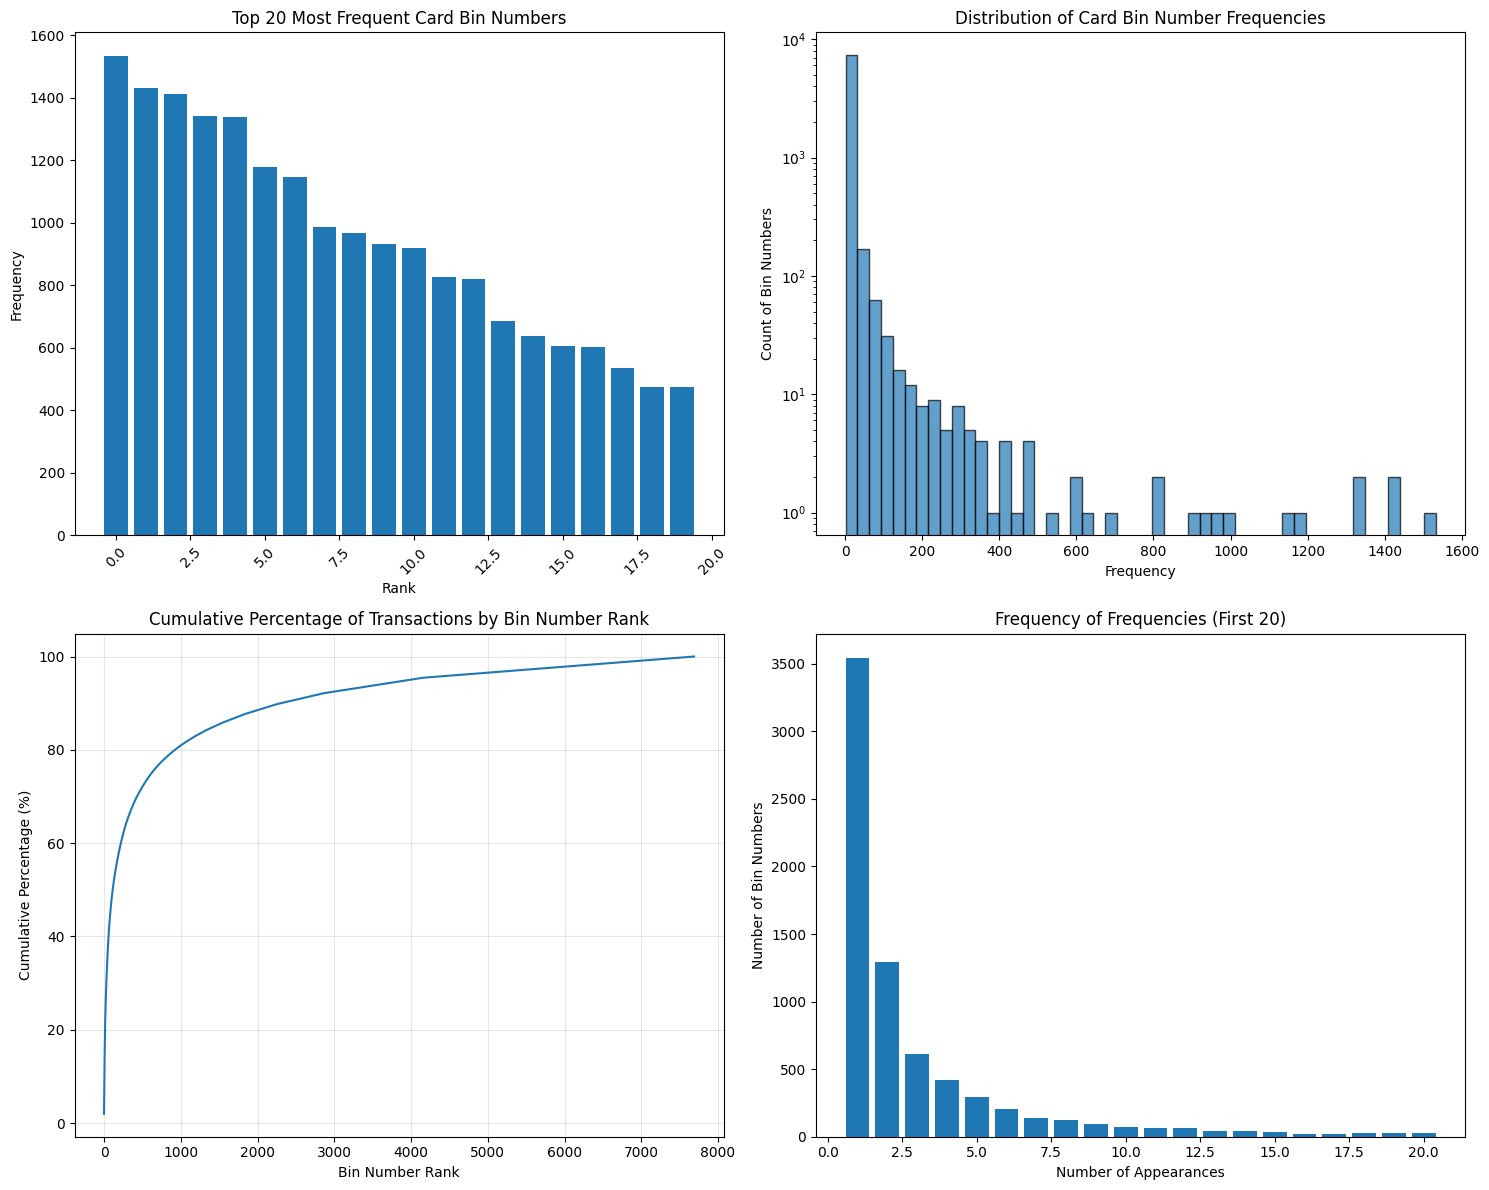


Coverage analysis:
Top 10 bin numbers cover: 15.79% of transactions
Top 50 bin numbers cover: 37.23% of transactions
Top 100 bin numbers cover: 48.09% of transactions
Top 500 bin numbers cover: 72.07% of transactions
BIN Database Info:
Shape: (374788, 10)
Columns: ['BIN', 'Brand', 'Type', 'Category', 'Issuer', 'IssuerPhone', 'IssuerUrl', 'isoCode2', 'isoCode3', 'CountryName']

First few rows of BIN database:
Total unique BINs in Decay_Data: 7689
Sample BINs from Decay_Data: [514377 515676 534456 546316 411773 412451 414720 420767 425836 434275]

Unique 6-digit BIN prefixes in Decay_Data: 7689

BIN database columns: ['BIN', 'Issuer']
Total BINs in BIN database: 374788

=== MATCHING RESULTS ===
BINs with matches: 7684
BINs without matches: 5
Match rate: 99.93%

Sample matched BINs: ['422082', '400895', '430746', '464917', '486243', '444735', '553951', '558749', '418546', '426420']
Sample unmatched BINs: ['512148', '559659', '545676', '521999', '514032']

=== TRANSACTION COVERAGE ===
Tra

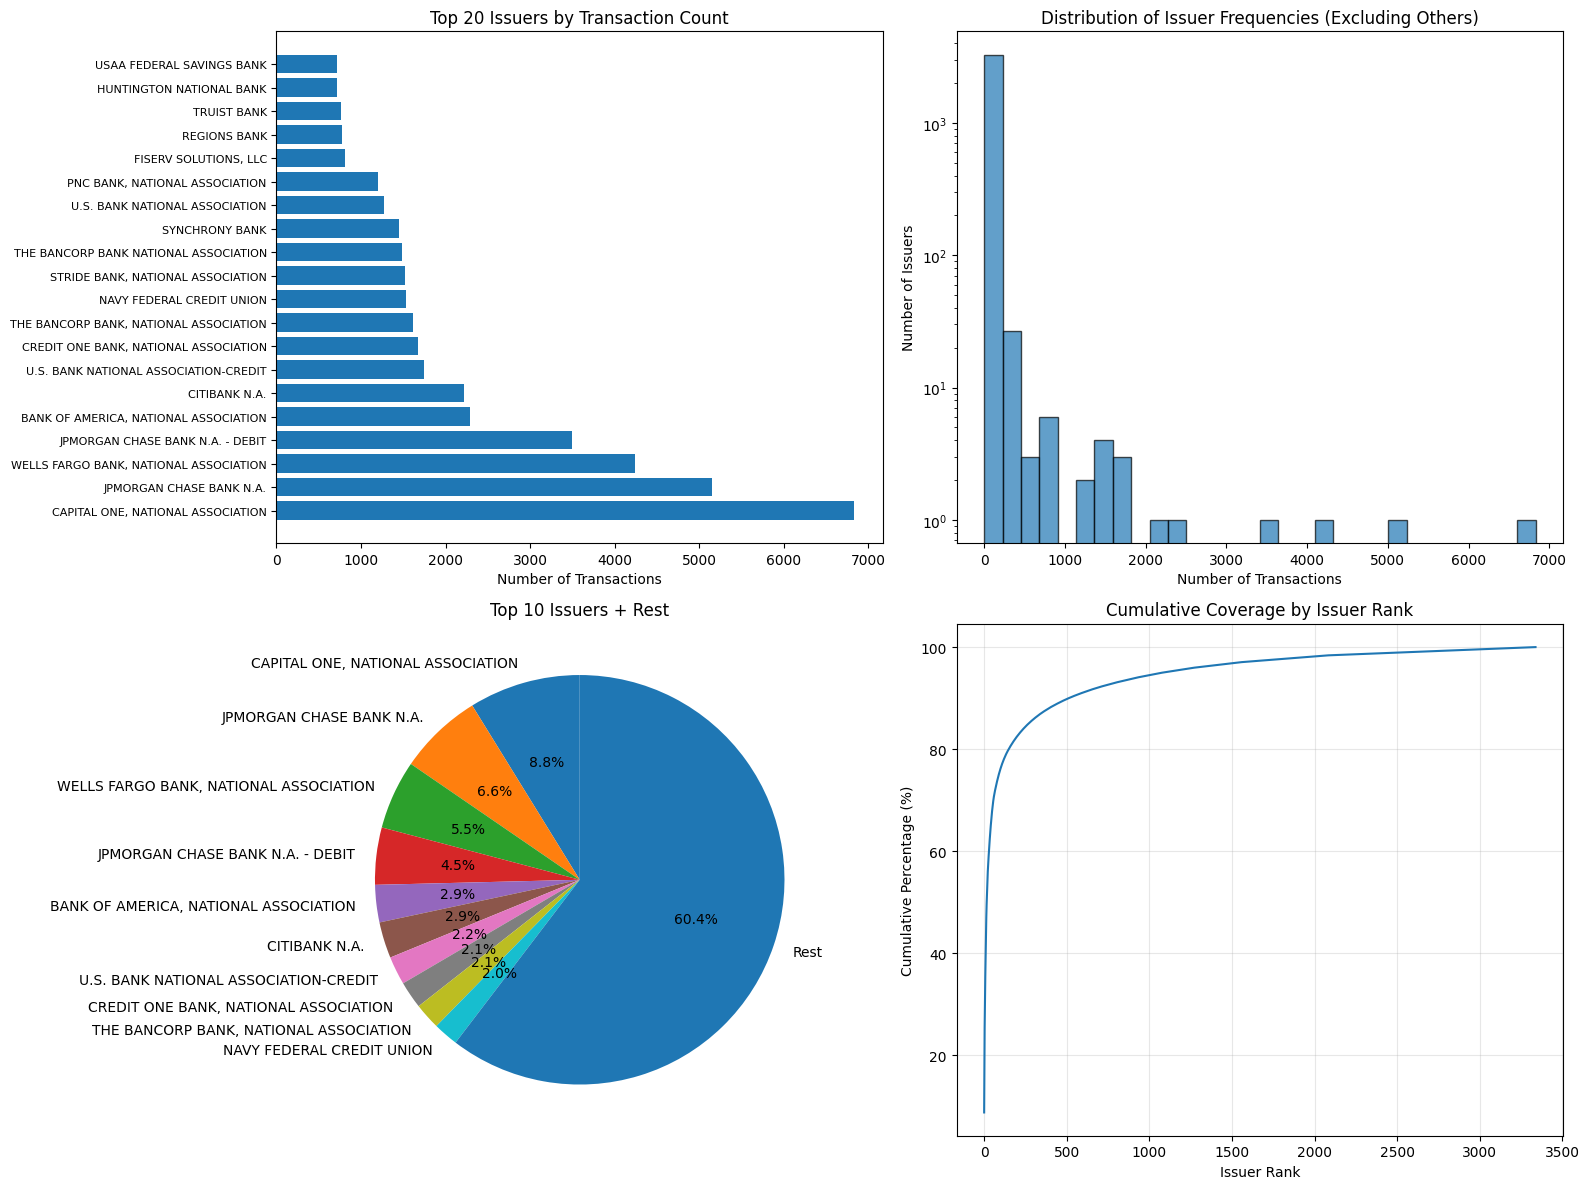


=== SUMMARY ===
Total unique issuers found: 3338
Top 10 issuers cover: 39.63% of transactions
Top 20 issuers cover: 53.42% of transactions
'Others' category: 0.01% of transactions


C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\1936436925.py:105: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\1936436925.py:105: UserWarning: Glyph 127974 (\N{BANK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\1936436925.py:105: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\1936436925.py:105: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\1936436925.py:105: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\mmsou\

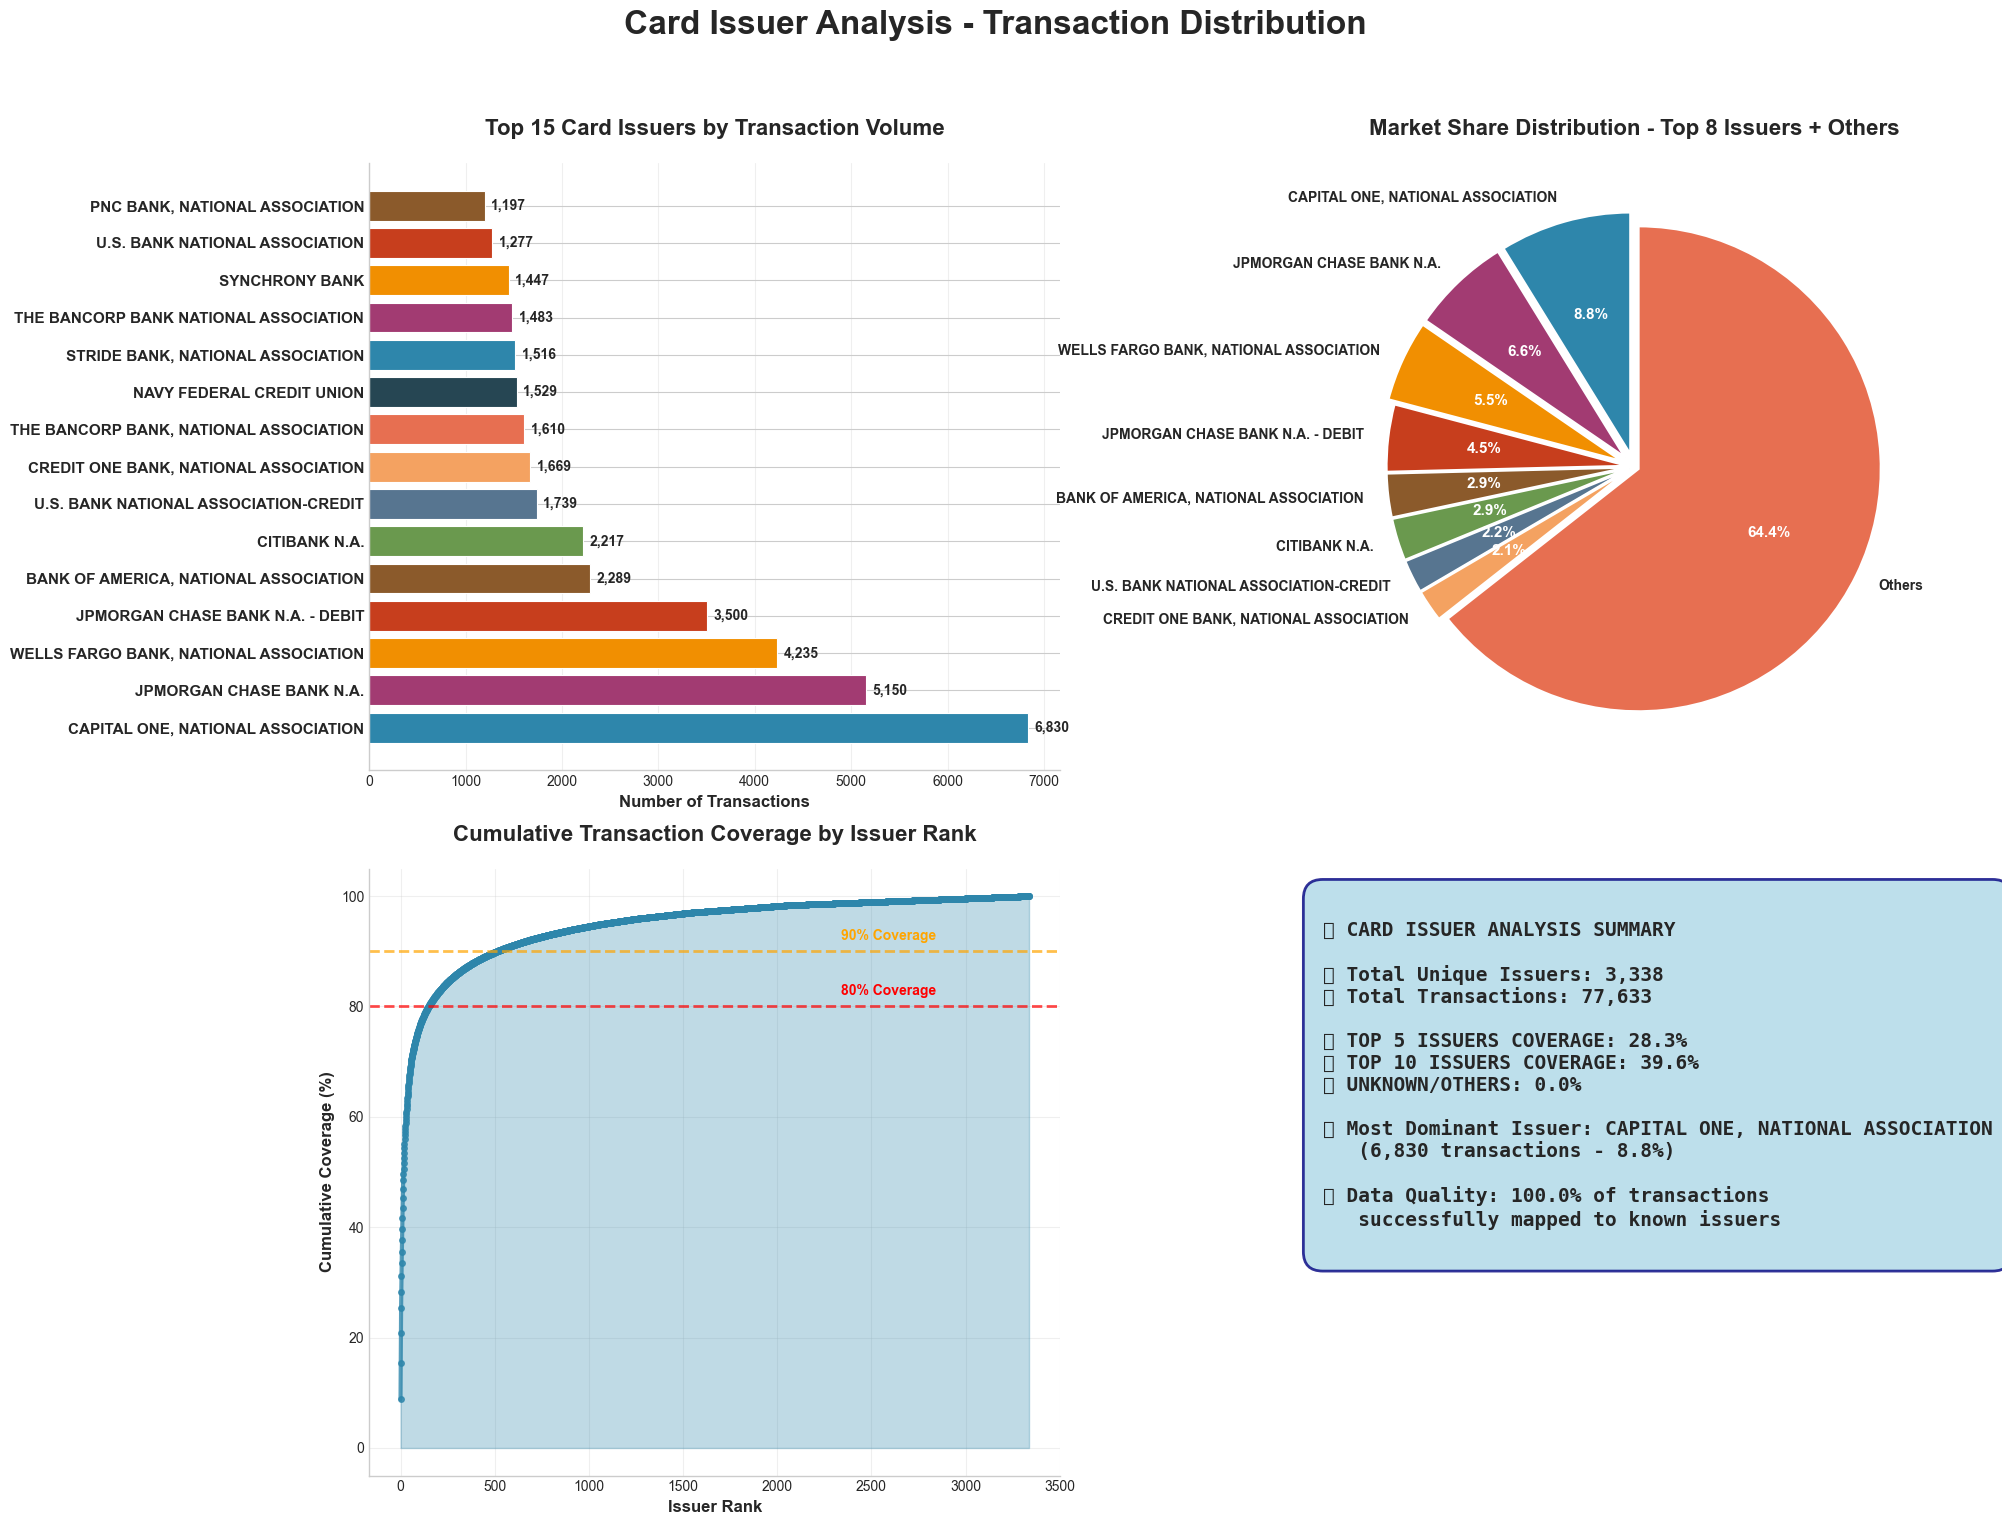

🏦 EXECUTIVE SUMMARY - CARD ISSUER DISTRIBUTION
📊 Dataset Overview:
   • Total Transactions: 77,633
   • Unique Card Issuers: 3338
   • Data Completeness: 100.0%

💼 Market Concentration:
   • Top 3 Issuers: 20.9% of transactions
   • Top 5 Issuers: 28.3% of transactions
   • Top 10 Issuers: 39.6% of transactions

🏆 Leading Issuers:
   1. CAPITAL ONE, NATIONAL ASSOCIATION: 6,830 transactions (8.8%)
   2. JPMORGAN CHASE BANK N.A.: 5,150 transactions (6.6%)
   3. WELLS FARGO BANK, NATIONAL ASSOCIATION: 4,235 transactions (5.5%)
   4. JPMORGAN CHASE BANK N.A. - DEBIT: 3,500 transactions (4.5%)
   5. BANK OF AMERICA, NATIONAL ASSOCIATION: 2,289 transactions (2.9%)
The length of the bin_database is (7684, 2)
The number of unique BINs in the bin_database is 7684
=== CREATING BANK_ISSUER COLUMN USING BIN DATABASE MAPPING ===
Mapping BIN numbers to bank issuers using bin_database_dict...
Starting loop over 77,633 rows...
Processed 10,000 rows...
Processed 20,000 rows...
Processed 30,000 rows...


<>:14: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\1732857742.py:14: SyntaxWarning: invalid escape sequence '\$'
  df[column] = df[column].replace('[\$,]', '', regex=True).astype(float)



Columns with object data type:
-----------------------------
_track_tracking_1_track
_track_tracking_2_track
attempted_charges
declined_charges
successful_charges
unique_cycle_attempts
declined_unique_cycle_attempts
successful_unique_cycle_attempts
cycle_1_attempts
cycle_1_success
cycle_1_decline
renewal_attempts
renewal_success
renewal_decline
successful_offers
item_quantity
successful_customers
refunds
voids
[ 11  14  16  17  19  20  22  24  25  27  28  29   3  30  31  32  33  34
  37  39   4  40  44  46  47  49   5  50  52  57  62  63  64  65  66  68
  69  71  75   8  81  41  48  51  53  59 100 101 102 103 104 105 110 111
 112  12  21  35  43  58  60  67   7  77  89  91  92  93  94  95  96  99
 116 117 118 119 120 124 125 126 127 128 129 131 132 133 134  87 135 136
 121 122 123 137 143 144  72  86  73  13  10  18   2  23  26  36  38  42
  45  56   6  61  70  76   9  97  98 107 106  -1]
=== ONE-HOT ENCODED COLUMNS ===
Total one-hot encoded columns found: 21

Charge Types (1 columns)

C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\3298242208.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)


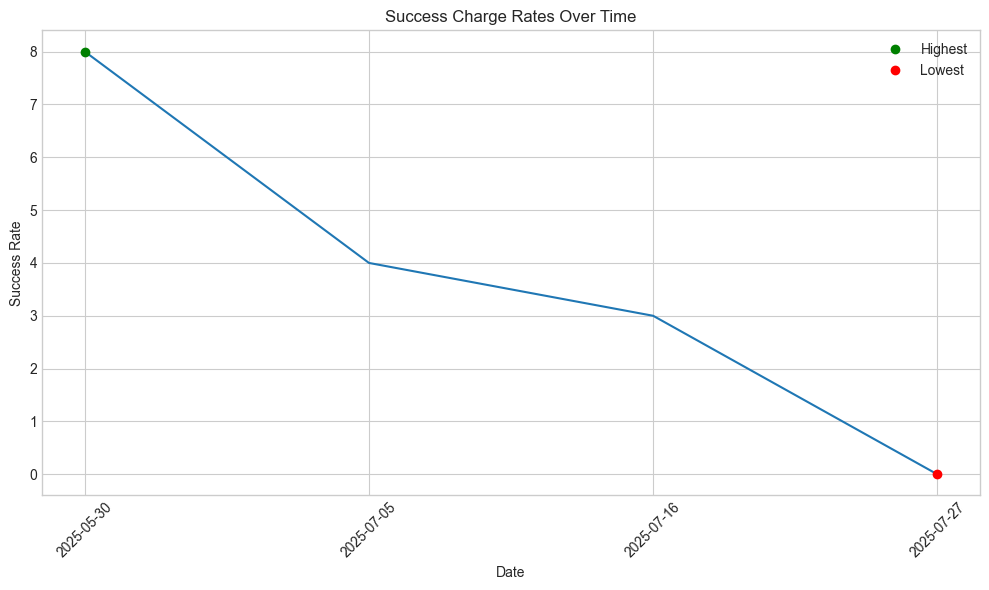

Highest success rate: 0.500 on 2025-05-30
Lowest success rate: 0.000 on 2025-07-27


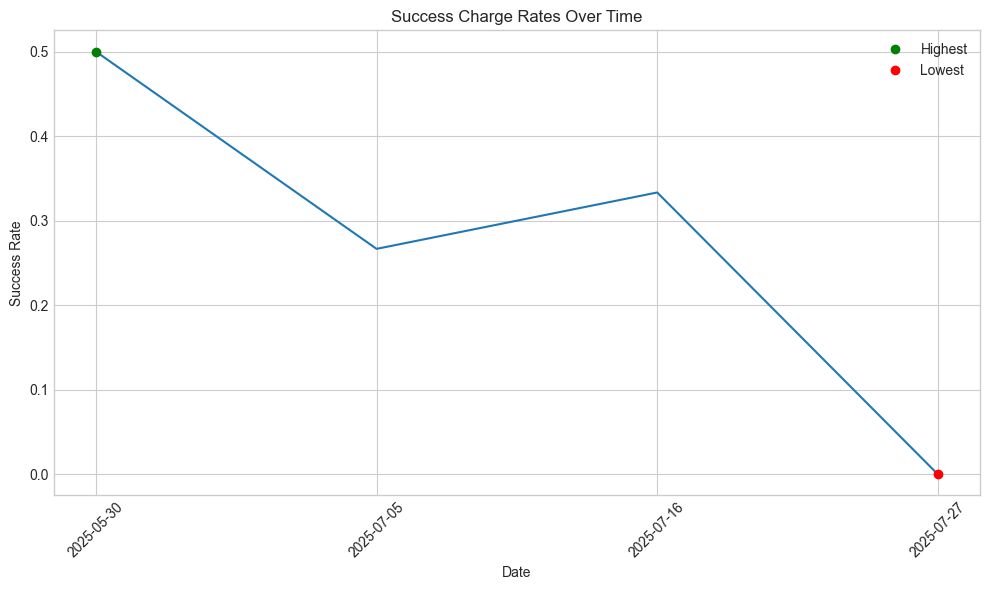

In [2]:
# Import objects from MID_Decay.ipynb
%run MID_Decay.ipynb

In [3]:
# Verify imported data
print("Available dataframes:")
print(f"mid_dataframes_uncleaned type: {type(mid_dataframes_uncleaned)}")
if isinstance(mid_dataframes_uncleaned, dict):
    print(f"Keys: {list(mid_dataframes_uncleaned.keys())}")
elif isinstance(mid_dataframes_uncleaned, pd.DataFrame):
    print(f"Shape: {mid_dataframes_uncleaned.shape}")
    print(f"Columns: {mid_dataframes_uncleaned.columns.tolist()}")

Available dataframes:
mid_dataframes_uncleaned type: <class 'dict'>
Keys: ['11_df', '14_df', '16_df', '17_df', '19_df', '20_df', '22_df', '24_df', '25_df', '27_df', '28_df', '29_df', '3_df', '30_df', '31_df', '32_df', '33_df', '34_df', '37_df', '39_df', '4_df', '40_df', '44_df', '46_df', '47_df', '49_df', '5_df', '50_df', '52_df', '57_df', '62_df', '63_df', '64_df', '65_df', '66_df', '68_df', '69_df', '71_df', '75_df', '8_df', '81_df', '41_df', '48_df', '51_df', '53_df', '59_df', '100_df', '101_df', '102_df', '103_df', '104_df', '105_df', '110_df', '111_df', '112_df', '12_df', '21_df', '35_df', '43_df', '58_df', '60_df', '67_df', '7_df', '77_df', '89_df', '91_df', '92_df', '93_df', '94_df', '95_df', '96_df', '99_df', '116_df', '117_df', '118_df', '119_df', '120_df', '124_df', '125_df', '126_df', '127_df', '128_df', '129_df', '131_df', '132_df', '133_df', '134_df', '87_df', '135_df', '136_df', '121_df', '122_df', '123_df', '137_df', '143_df', '144_df', '72_df', '86_df', '73_df', '13_df'

## Data Preparation for Modeling

In [4]:
# Aggregate to one row per date–mid–affiliate–product (adjust col names if needed)
def aggregate_by_key(df, product_col='item', affiliate_col='affiliate_id'):
    df = df.copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date']).dt.date

    key_cols = [c for c in ['date', 'mid', affiliate_col, product_col] if c in df.columns]
    non_key = [c for c in df.columns if c not in key_cols]

    # Identify columns
    binary_cols = [c for c in non_key if df[c].dropna().isin([0,1]).all()]
    rate_cols = [c for c in non_key if ('rate' in c and c not in binary_cols)]
    numeric_cols = df[non_key].select_dtypes(include='number').columns.tolist()
    sum_cols = [c for c in numeric_cols if c not in binary_cols + rate_cols]
    first_cols = [c for c in non_key if c not in binary_cols + rate_cols + sum_cols]

    agg = {**{c:'max' for c in binary_cols},
           **{c:'mean' for c in rate_cols},
           **{c:'sum' for c in sum_cols},
           **{c:'first' for c in first_cols}}

    out = df.groupby(key_cols, as_index=False).agg(agg)
    for c in binary_cols:
        out[c] = out[c].astype('uint8')
    return out

# Build pooled_df directly from all MID frames (no per-MID loop needed)
all_df = pd.concat(mid_dataframes_uncleaned.values(), ignore_index=True)
pooled_df = aggregate_by_key(all_df, product_col='item', affiliate_col='affiliate_id')

# sanity
print(sorted(pooled_df.get('_track_tracking_1_track', pd.Series()).unique()))

[1, 15]


In [5]:
pooled_df.shape

(6869, 101)

In [6]:
# Drop columns that are all zeros or start with 'processor_'
zero_cols = [col for col in pooled_df.columns if (pooled_df[col] == 0).all()]
processor_cols = [col for col in pooled_df.columns if col.startswith('processor_')]
cols_to_drop = list(set(zero_cols + processor_cols))
print(cols_to_drop)
pooled_df = pooled_df.drop(columns=cols_to_drop)



['renewal_decline', 'alert_fees_rate', 'cycle_1_cost_of_goods_sold']


In [7]:
# Rename columns containing 'porcezzor_' to 'processor_'
for column in pooled_df.columns:
    if "procezzor_" in column:
        new_column = column.replace("procezzor_", "processor_")
        pooled_df = pooled_df.rename(columns={column: new_column})
        print(f"Renamed {column} to {new_column}")

Renamed procezzor_apps to processor_apps
Renamed procezzor_bmo_har to processor_bmo_har
Renamed procezzor_cbsl to processor_cbsl
Renamed procezzor_esq to processor_esq
Renamed procezzor_evo to processor_evo
Renamed procezzor_luqra_evo to processor_luqra_evo
Renamed procezzor_merchantindustries to processor_merchantindustries
Renamed procezzor_net to processor_net
Renamed procezzor_net_esq to processor_net_esq
Renamed procezzor_payarc to processor_payarc
Renamed procezzor_payarc_evo to processor_payarc_evo
Renamed procezzor_prior to processor_prior
Renamed procezzor_prior_syn to processor_prior_syn
Renamed procezzor_psf to processor_psf
Renamed procezzor_psf_bbva to processor_psf_bbva
Renamed procezzor_quant to processor_quant
Renamed procezzor_quant_cbsl to processor_quant_cbsl
Renamed procezzor_signa to processor_signa
Renamed procezzor_signa_cbc to processor_signa_cbc
Renamed procezzor_signapay to processor_signapay
Renamed procezzor_syn to processor_syn
Renamed procezzor_unknown to 

# **ROUND 2 START**


#### **Ok so now what we have is the data pooled as we had before, we have fixed the processor thing too. We also ofc have the affilite ids and products used, so now is where the real Analysis starts**

In [8]:
pooled_df = pooled_df.rename(columns={'_track_tracking_1_track': 'affiliate_id', '_track_tracking_2_track': 'product'})


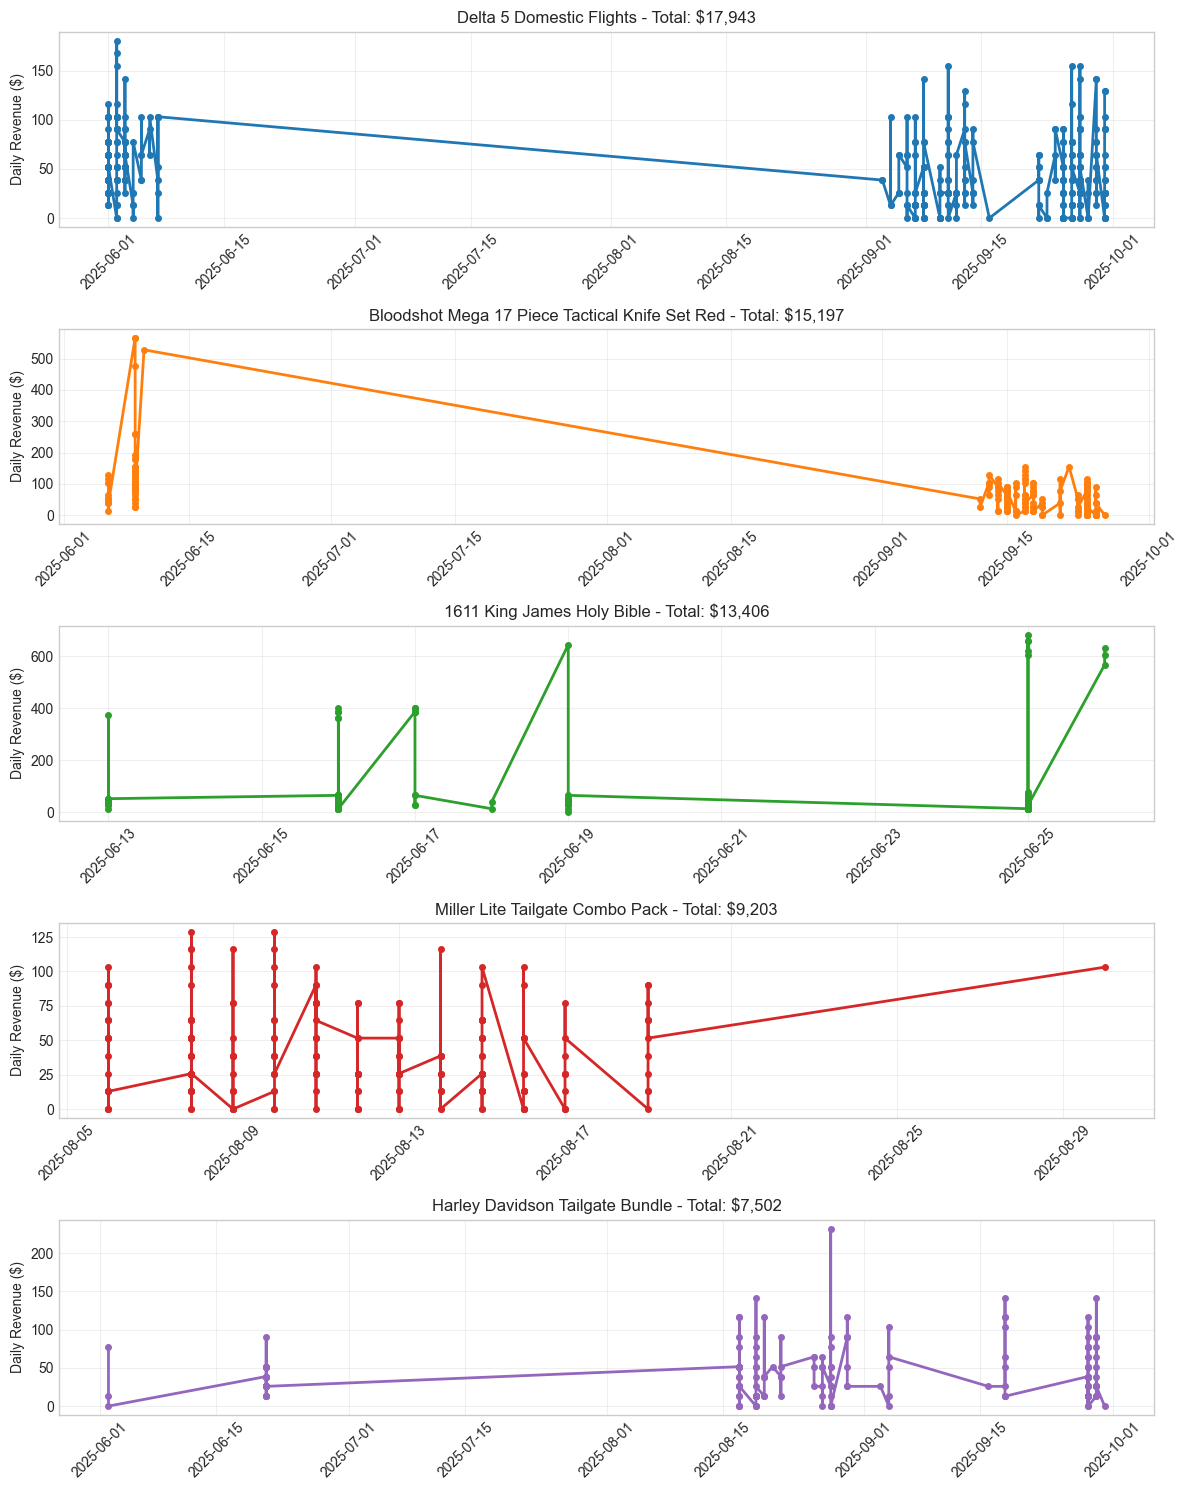

In [9]:
def plot_top_products_revenue_simple(df, affiliate_id, top_n=5):
    """
    Simple plots of revenue over time for top N products by revenue
    """
    import matplotlib.pyplot as plt
    
    # Filter for specific affiliate
    affiliate_data = df[df['affiliate_id'] == affiliate_id].copy()
    
    # Get top products by total revenue
    top_products = affiliate_data.groupby('product')['gross_product_revenue'].sum().nlargest(top_n)
    
    # Convert date column to datetime
    affiliate_data['date'] = pd.to_datetime(affiliate_data['date'])
    
    # Create subplots
    fig, axes = plt.subplots(top_n, 1, figsize=(12, 3*top_n))
    if top_n == 1:
        axes = [axes]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, (product_name, total_rev) in enumerate(top_products.items()):
        # Filter data for this product
        product_data = affiliate_data[affiliate_data['product'] == product_name].copy()
        product_data = product_data.sort_values('date')
        
        # Plot revenue
        axes[i].plot(product_data['date'], product_data['gross_product_revenue'], 
                    color=colors[i], linewidth=2, marker='o', markersize=4)
        axes[i].set_title(f'{product_name} - Total: ${total_rev:,.0f}')
        axes[i].set_ylabel('Daily Revenue ($)')
        axes[i].grid(True, alpha=0.3)
        
        # Rotate x-axis labels
        plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

# Plot top 5 products for Affiliate 1
plot_top_products_revenue_simple(pooled_df, affiliate_id=1, top_n=5)

## **Checking stats comparisosn between the two affiliates**

In [10]:
# Standard deviation of success rates for each affiliate
print("SUCCESS RATE STANDARD DEVIATIONS")
print("="*40)

aff1_std = pooled_df[pooled_df['affiliate_id'] == 1]['success_charge_ratess'].std()
aff15_std = pooled_df[pooled_df['affiliate_id'] == 15]['success_charge_ratess'].std()

print(f"Affiliate 1:  {aff1_std:.4f} ({aff1_std*100:.2f}%)")
print(f"Affiliate 15: {aff15_std:.4f} ({aff15_std*100:.2f}%)")
print(f"\nDifference:   {abs(aff1_std - aff15_std):.4f}")

if aff1_std > aff15_std:
    print(f"Affiliate 1 has {((aff1_std/aff15_std - 1) * 100):.1f}% more variance")
else:
    print(f"Affiliate 15 has {((aff15_std/aff1_std - 1) * 100):.1f}% more variance")

SUCCESS RATE STANDARD DEVIATIONS
Affiliate 1:  0.2254 (22.54%)
Affiliate 15: 0.1836 (18.36%)

Difference:   0.0418
Affiliate 1 has 22.7% more variance


#### **2) Checking stats comparisosn between the two affiliates - Top and worst products**

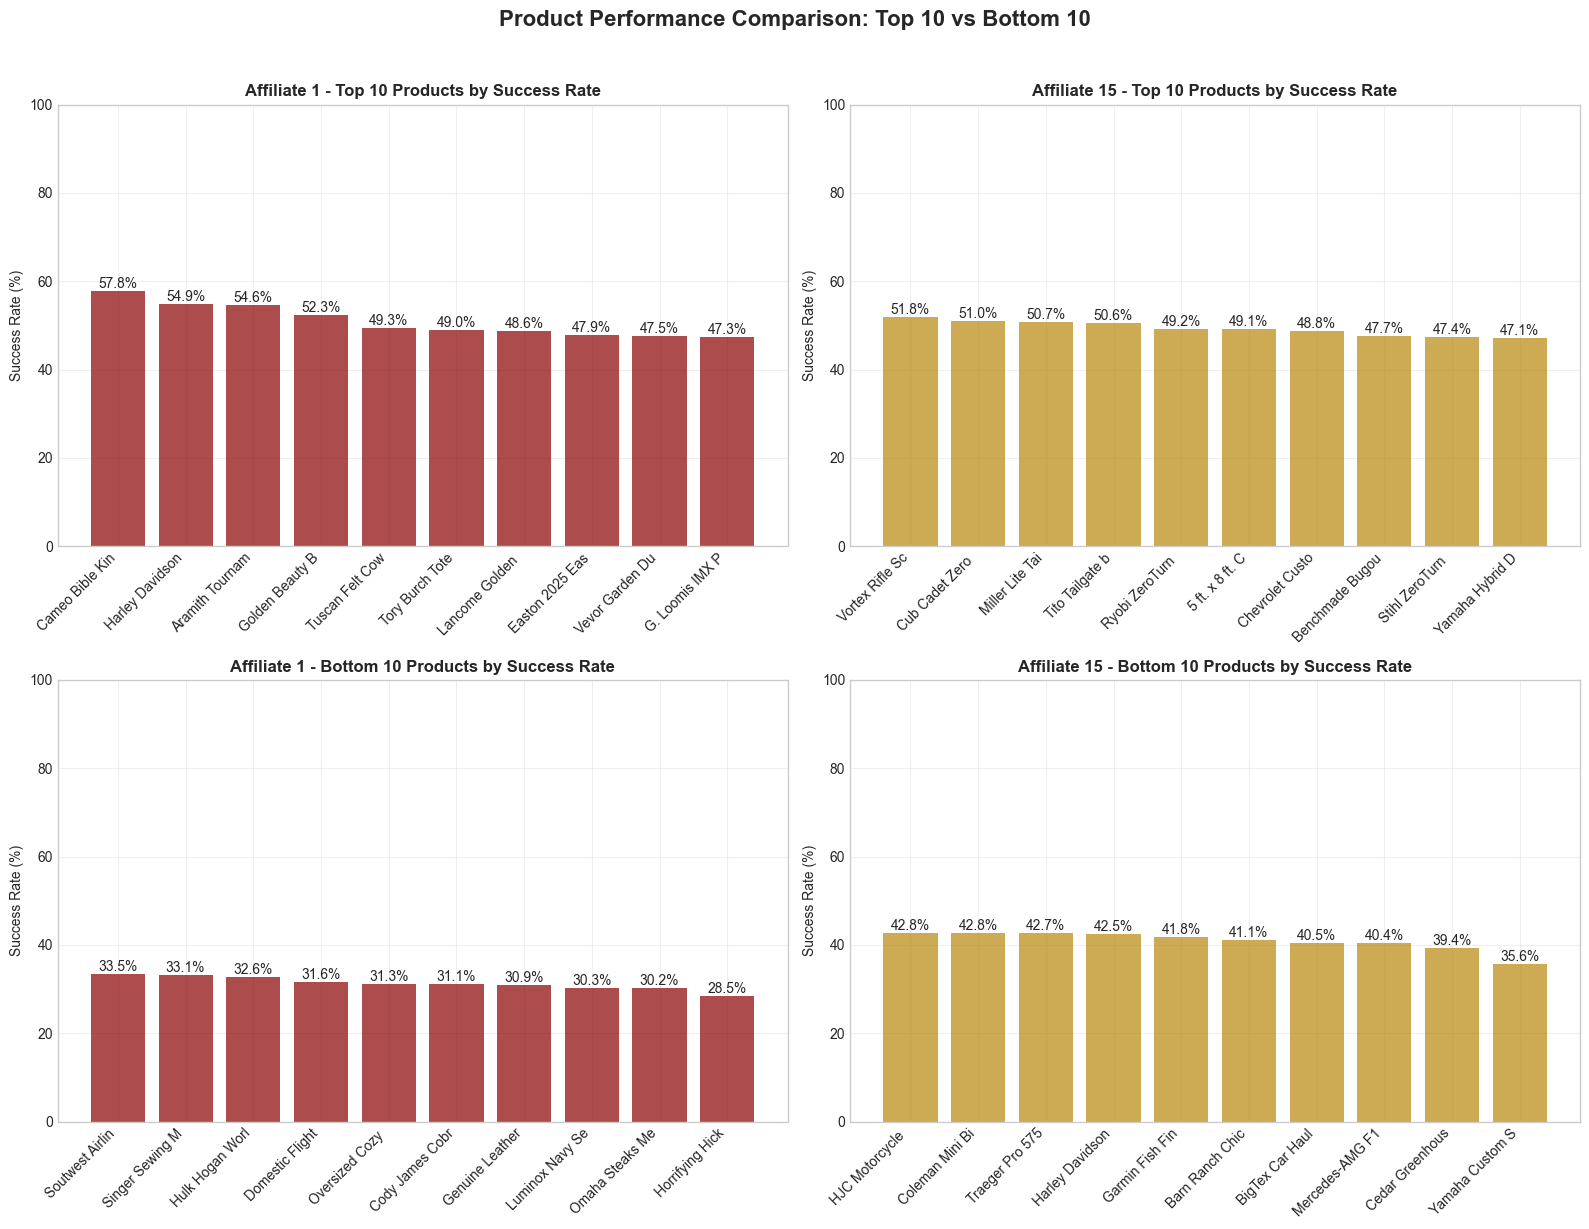

In [11]:
# Combined visualization: Top 10 and Bottom 10 products for both affiliates
import matplotlib.pyplot as plt

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# AFFILIATE 1 - TOP 10
aff1_data = pooled_df[pooled_df['affiliate_id'] == 1]
aff1_product_success = aff1_data.groupby('product').agg({
    'success_charge_ratess': 'mean',
    'attempted_charges': 'sum',
    'gross_product_revenue': 'sum'
}).reset_index()
aff1_product_success = aff1_product_success[aff1_product_success['attempted_charges'] >= 100]
aff1_product_success_sorted = aff1_product_success.sort_values('success_charge_ratess', ascending=False)
aff1_top10 = aff1_product_success_sorted.head(10)

bars1 = ax1.bar(range(len(aff1_top10)), aff1_top10['success_charge_ratess'] * 100, color='darkred', alpha=0.7)
ax1.set_xticks(range(len(aff1_top10)))
ax1.set_xticklabels([p[:15] for p in aff1_top10['product']], rotation=45, ha='right')
ax1.set_ylabel('Success Rate (%)')
ax1.set_title('Affiliate 1 - Top 10 Products by Success Rate', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

# AFFILIATE 15 - TOP 10
aff15_data = pooled_df[pooled_df['affiliate_id'] == 15]
aff15_product_success = aff15_data.groupby('product').agg({
    'success_charge_ratess': 'mean',
    'attempted_charges': 'sum',
    'gross_product_revenue': 'sum'
}).reset_index()
aff15_product_success = aff15_product_success[aff15_product_success['attempted_charges'] >= 100]
aff15_product_success_sorted = aff15_product_success.sort_values('success_charge_ratess', ascending=False)
aff15_top10 = aff15_product_success_sorted.head(10)

bars2 = ax2.bar(range(len(aff15_top10)), aff15_top10['success_charge_ratess'] * 100, color='darkgoldenrod', alpha=0.7)
ax2.set_xticks(range(len(aff15_top10)))
ax2.set_xticklabels([p[:15] for p in aff15_top10['product']], rotation=45, ha='right')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Affiliate 15 - Top 10 Products by Success Rate', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

# AFFILIATE 1 - BOTTOM 10
aff1_bottom10 = aff1_product_success_sorted.tail(10)

bars3 = ax3.bar(range(len(aff1_bottom10)), aff1_bottom10['success_charge_ratess'] * 100, color='darkred', alpha=0.7)
ax3.set_xticks(range(len(aff1_bottom10)))
ax3.set_xticklabels([p[:15] for p in aff1_bottom10['product']], rotation=45, ha='right')
ax3.set_ylabel('Success Rate (%)')
ax3.set_title('Affiliate 1 - Bottom 10 Products by Success Rate', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 100)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

# AFFILIATE 15 - BOTTOM 10
aff15_bottom10 = aff15_product_success_sorted.tail(10)

bars4 = ax4.bar(range(len(aff15_bottom10)), aff15_bottom10['success_charge_ratess'] * 100, color='darkgoldenrod', alpha=0.7)
ax4.set_xticks(range(len(aff15_bottom10)))
ax4.set_xticklabels([p[:15] for p in aff15_bottom10['product']], rotation=45, ha='right')
ax4.set_ylabel('Success Rate (%)')
ax4.set_title('Affiliate 15 - Bottom 10 Products by Success Rate', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 100)

for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

plt.suptitle('Product Performance Comparison: Top 10 vs Bottom 10', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### **3) Checking stats comparisosn between the two affiliates - Processor Analysis and Average Success Rates per Processor**

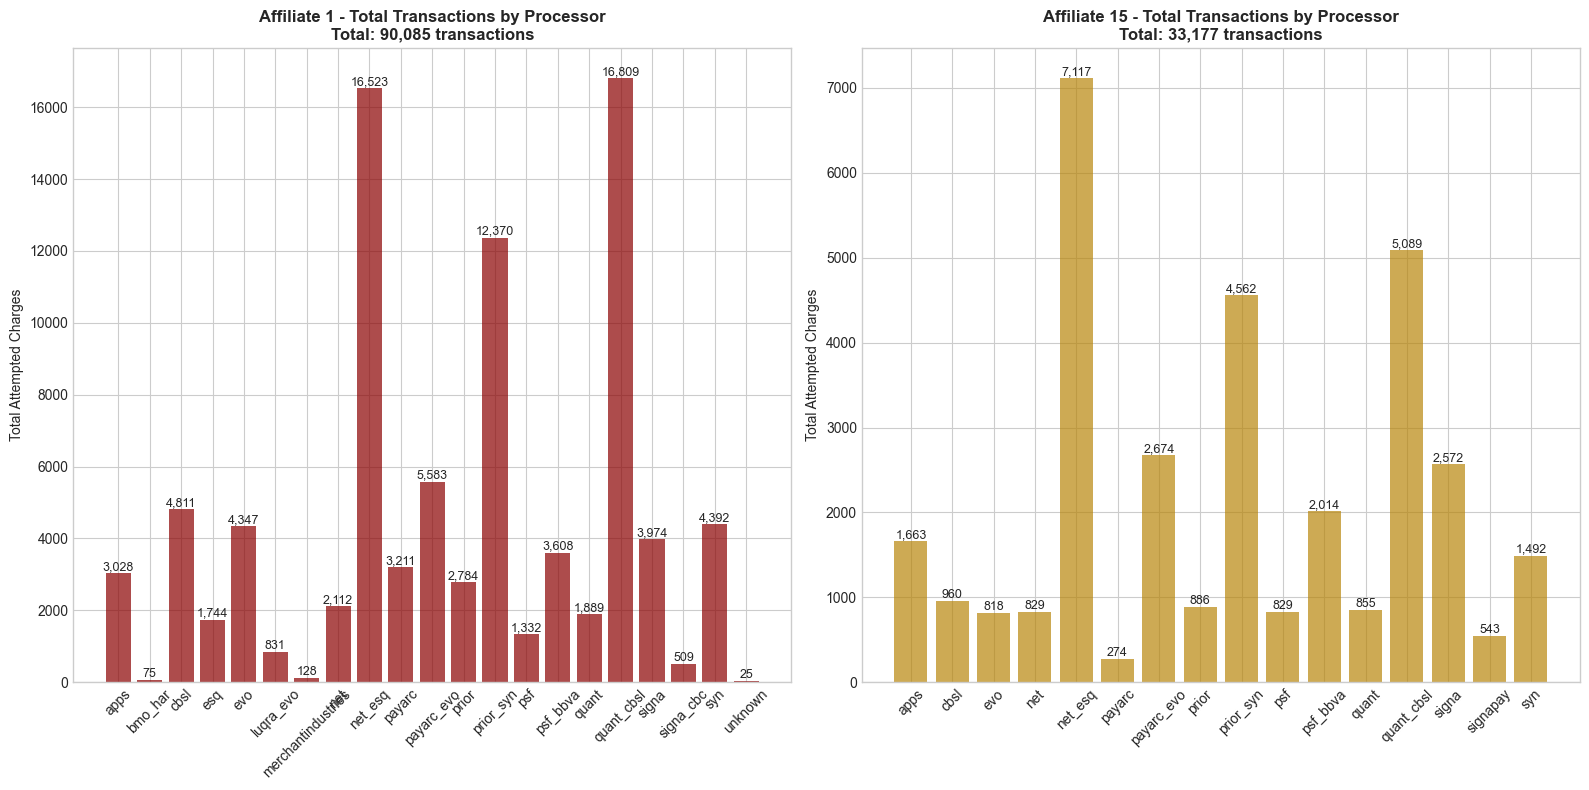


PROCESSOR USAGE COMPARISON:

AFFILIATE 1 PROCESSORS:
------------------------------
quant_cbsl          : 16,809 transactions
net_esq             : 16,523 transactions
prior_syn           : 12,370 transactions
payarc_evo          : 5,583 transactions
cbsl                : 4,811 transactions
syn                 : 4,392 transactions
evo                 : 4,347 transactions
signa               : 3,974 transactions
psf_bbva            : 3,608 transactions
payarc              : 3,211 transactions
apps                : 3,028 transactions
prior               : 2,784 transactions
net                 : 2,112 transactions
quant               : 1,889 transactions
esq                 : 1,744 transactions
psf                 : 1,332 transactions
luqra_evo           : 831 transactions
signa_cbc           : 509 transactions
merchantindustries  : 128 transactions
bmo_har             : 75 transactions
unknown             : 25 transactions

AFFILIATE 15 PROCESSORS:
------------------------------
net_es

In [12]:
def compare_processor_usage(df):
    """
    Compare processor usage between affiliates 1 and 15
    Shows bar charts for transaction volume by processor
    """
    import matplotlib.pyplot as plt
    
    # Get processor columns (those starting with 'processor_')
    processor_cols = [col for col in df.columns if col.startswith('processor_')]
    
    # Filter data for both affiliates
    aff1_data = df[df['affiliate_id'] == 1]
    aff15_data = df[df['affiliate_id'] == 15]
    
    # Calculate total transactions per processor for each affiliate
    aff1_processors = {}
    aff15_processors = {}
    
    for processor in processor_cols:
        # Sum up all transactions where this processor = 1
        aff1_total = aff1_data[aff1_data[processor] == 1]['attempted_charges'].sum()
        aff15_total = aff15_data[aff15_data[processor] == 1]['attempted_charges'].sum()
        
        if aff1_total > 0:
            aff1_processors[processor.replace('processor_', '')] = aff1_total
        if aff15_total > 0:
            aff15_processors[processor.replace('processor_', '')] = aff15_total
    
    # Create comparison plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Affiliate 1 bar chart
    if aff1_processors:
        processors1 = list(aff1_processors.keys())
        volumes1 = list(aff1_processors.values())
        bars1 = ax1.bar(processors1, volumes1, color='darkred', alpha=0.7)
        ax1.set_title(f'Affiliate 1 - Total Transactions by Processor\nTotal: {sum(volumes1):,} transactions', fontweight='bold')
        ax1.set_ylabel('Total Attempted Charges')
        ax1.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, volume in zip(bars1, volumes1):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{volume:,}', ha='center', va='bottom', fontsize=9)
    
    # Affiliate 15 bar chart  
    if aff15_processors:
        processors15 = list(aff15_processors.keys())
        volumes15 = list(aff15_processors.values())
        bars2 = ax2.bar(processors15, volumes15, color='darkgoldenrod', alpha=0.7)
        ax2.set_title(f'Affiliate 15 - Total Transactions by Processor\nTotal: {sum(volumes15):,} transactions', fontweight='bold')
        ax2.set_ylabel('Total Attempted Charges')
        ax2.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, volume in zip(bars2, volumes15):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{volume:,}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary tables
    print("\nPROCESSOR USAGE COMPARISON:")
    print("="*50)
    print(f"\nAFFILIATE 1 PROCESSORS:")
    print("-"*30)
    for processor, volume in sorted(aff1_processors.items(), key=lambda x: x[1], reverse=True):
        print(f"{processor:20}: {volume:,} transactions")
    
    print(f"\nAFFILIATE 15 PROCESSORS:")
    print("-"*30)
    for processor, volume in sorted(aff15_processors.items(), key=lambda x: x[1], reverse=True):
        print(f"{processor:20}: {volume:,} transactions")
    
    return aff1_processors, aff15_processors

# Compare processor usage between affiliates
aff1_proc, aff15_proc = compare_processor_usage(pooled_df)

C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\2575670437.py:74: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\mmsou\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


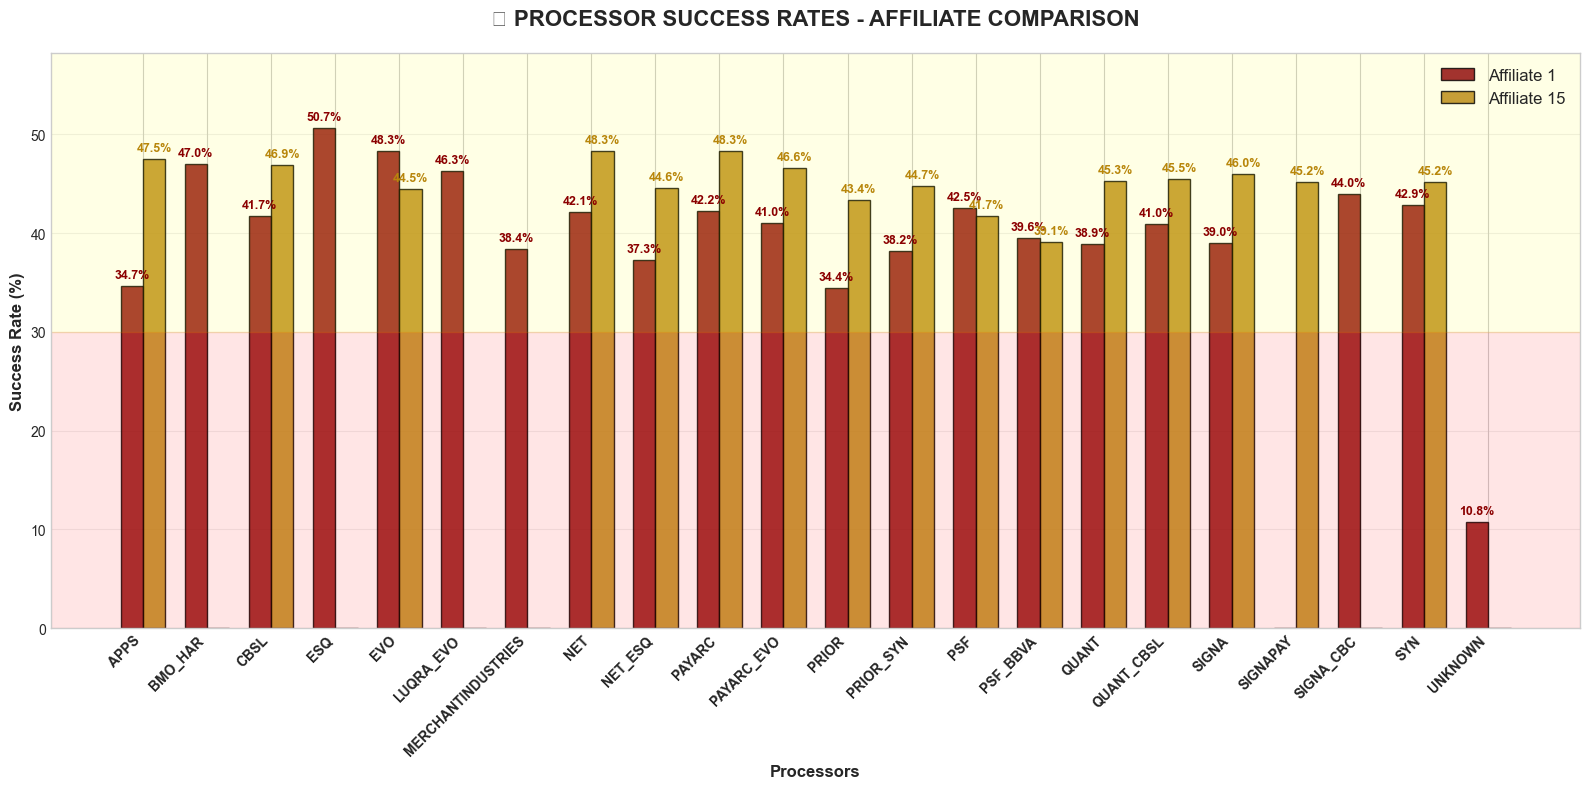


📈 PROCESSOR SUCCESS RATE COMPARISON BY AFFILIATE
Processor            Affiliate 1     Affiliate 15    Difference      Winner    
--------------------------------------------------------------------------------
APPS                 34.7            47.5            12.8            Aff 15    
BMO_HAR              47.0            N/A             N/A             Aff 1 only
CBSL                 41.7            46.9            5.2             Aff 15    
ESQ                  50.7            N/A             N/A             Aff 1 only
EVO                  48.3            44.5            3.8             Aff 1     
LUQRA_EVO            46.3            N/A             N/A             Aff 1 only
MERCHANTINDUSTRIES   38.4            N/A             N/A             Aff 1 only
NET                  42.1            48.3            6.2             Aff 15    
NET_ESQ              37.3            44.6            7.3             Aff 15    
PAYARC               42.2            48.3            6.1             

In [13]:
# Processor Success Rate Comparison - Side by Side Bars
import matplotlib.pyplot as plt
import numpy as np

# Get processor columns
processor_cols = [col for col in pooled_df.columns if col.startswith('processor_')]

# Calculate average success rate for each processor BY AFFILIATE
processor_performance_aff1 = {}
processor_performance_aff15 = {}

for processor in processor_cols:
    # AFFILIATE 1
    processor_data_aff1 = pooled_df[(pooled_df[processor] == 1) & (pooled_df['affiliate_id'] == 1)]
    if len(processor_data_aff1) > 0:
        avg_success = processor_data_aff1['success_charge_ratess'].mean()
        processor_name = processor.replace('processor_', '').upper()
        processor_performance_aff1[processor_name] = avg_success * 100
    
    # AFFILIATE 15
    processor_data_aff15 = pooled_df[(pooled_df[processor] == 1) & (pooled_df['affiliate_id'] == 15)]
    if len(processor_data_aff15) > 0:
        avg_success = processor_data_aff15['success_charge_ratess'].mean()
        processor_name = processor.replace('processor_', '').upper()
        processor_performance_aff15[processor_name] = avg_success * 100

# Get all processors used by either affiliate
all_processors = set(processor_performance_aff1.keys()) | set(processor_performance_aff15.keys())
all_processors = sorted(list(all_processors))

# Prepare data for plotting
aff1_rates = [processor_performance_aff1.get(proc, 0) for proc in all_processors]
aff15_rates = [processor_performance_aff15.get(proc, 0) for proc in all_processors]

# Create the visualization
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(all_processors))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, aff1_rates, width, label='Affiliate 1', 
               color='darkred', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, aff15_rates, width, label='Affiliate 15', 
               color='darkgoldenrod', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels on bars
for i, (bar1, bar2, rate1, rate2) in enumerate(zip(bars1, bars2, aff1_rates, aff15_rates)):
    if rate1 > 0:  # Only show label if processor is used by affiliate 1
        height1 = bar1.get_height()
        ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.5,
                f'{rate1:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9, color='darkred')
    
    if rate2 > 0:  # Only show label if processor is used by affiliate 15
        height2 = bar2.get_height()
        ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.5,
                f'{rate2:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9, color='darkgoldenrod')

# Customize the plot
ax.set_xlabel('Processors', fontsize=12, fontweight='bold')
ax.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('💳 PROCESSOR SUCCESS RATES - AFFILIATE COMPARISON', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(all_processors, rotation=45, ha='right', fontweight='bold')
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(max(aff1_rates), max(aff15_rates)) * 1.15)

# Add performance zones
ax.axhspan(0, 30, alpha=0.1, color='red', label='Poor')
ax.axhspan(30, 60, alpha=0.1, color='yellow', label='Average')
ax.axhspan(60, 100, alpha=0.1, color='green', label='Excellent')

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n" + "="*80)
print("📈 PROCESSOR SUCCESS RATE COMPARISON BY AFFILIATE")
print("="*80)
print(f"{'Processor':<20} {'Affiliate 1':<15} {'Affiliate 15':<15} {'Difference':<15} {'Winner':<10}")
print("-"*80)

for processor in all_processors:
    aff1_rate = processor_performance_aff1.get(processor, 0)
    aff15_rate = processor_performance_aff15.get(processor, 0)
    
    if aff1_rate > 0 and aff15_rate > 0:  # Both affiliates use this processor
        diff = abs(aff1_rate - aff15_rate)
        winner = "Aff 1" if aff1_rate > aff15_rate else "Aff 15"
        print(f"{processor:<20} {aff1_rate:<15.1f} {aff15_rate:<15.1f} {diff:<15.1f} {winner:<10}")
    elif aff1_rate > 0:  # Only affiliate 1 uses this processor
        print(f"{processor:<20} {aff1_rate:<15.1f} {'N/A':<15} {'N/A':<15} {'Aff 1 only':<10}")
    elif aff15_rate > 0:  # Only affiliate 15 uses this processor
        print(f"{processor:<20} {'N/A':<15} {aff15_rate:<15.1f} {'N/A':<15} {'Aff 15 only':<10}")

print(f"\n📊 SUMMARY STATISTICS:")
print(f"Processors used by Affiliate 1: {len([p for p in processor_performance_aff1.values() if p > 0])}")
print(f"Processors used by Affiliate 15: {len([p for p in processor_performance_aff15.values() if p > 0])}")
common_count = len(set(processor_performance_aff1.keys()) & set(processor_performance_aff15.keys()))
print(f"Processors used by both: {common_count}")

In [14]:
pooled_df.columns

Index(['date', 'mid', 'renewal_attempts', 'renewal_success',
       'renewal_success_rate', 'refunds', 'voids', 'processor_apps',
       'processor_bmo_har', 'processor_cbsl', 'processor_esq', 'processor_evo',
       'processor_luqra_evo', 'processor_merchantindustries', 'processor_net',
       'processor_net_esq', 'processor_payarc', 'processor_payarc_evo',
       'processor_prior', 'processor_prior_syn', 'processor_psf',
       'processor_psf_bbva', 'processor_quant', 'processor_quant_cbsl',
       'processor_signa', 'processor_signa_cbc', 'processor_signapay',
       'processor_syn', 'processor_unknown', 'charge_dp1_v3',
       'cardtype_mastercard', 'cardtype_visa', 'dayofweek_friday',
       'dayofweek_thursday', 'dayofweek_monday', 'dayofweek_wednesday',
       'dayofweek_sunday', 'dayofweek_saturday', 'dayofweek_tuesday',
       'bankissuer_navy_federal_credit_union',
       'bankissuer_us_bank_national_association-credit',
       'bankissuer_capital_one_national_association',
 

#### **4) Checking stats comparisosn between the two affiliates - Bank Issuers**

C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\941692131.py:68: UserWarning: Glyph 127974 (\N{BANK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\mmsou\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127974 (\N{BANK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


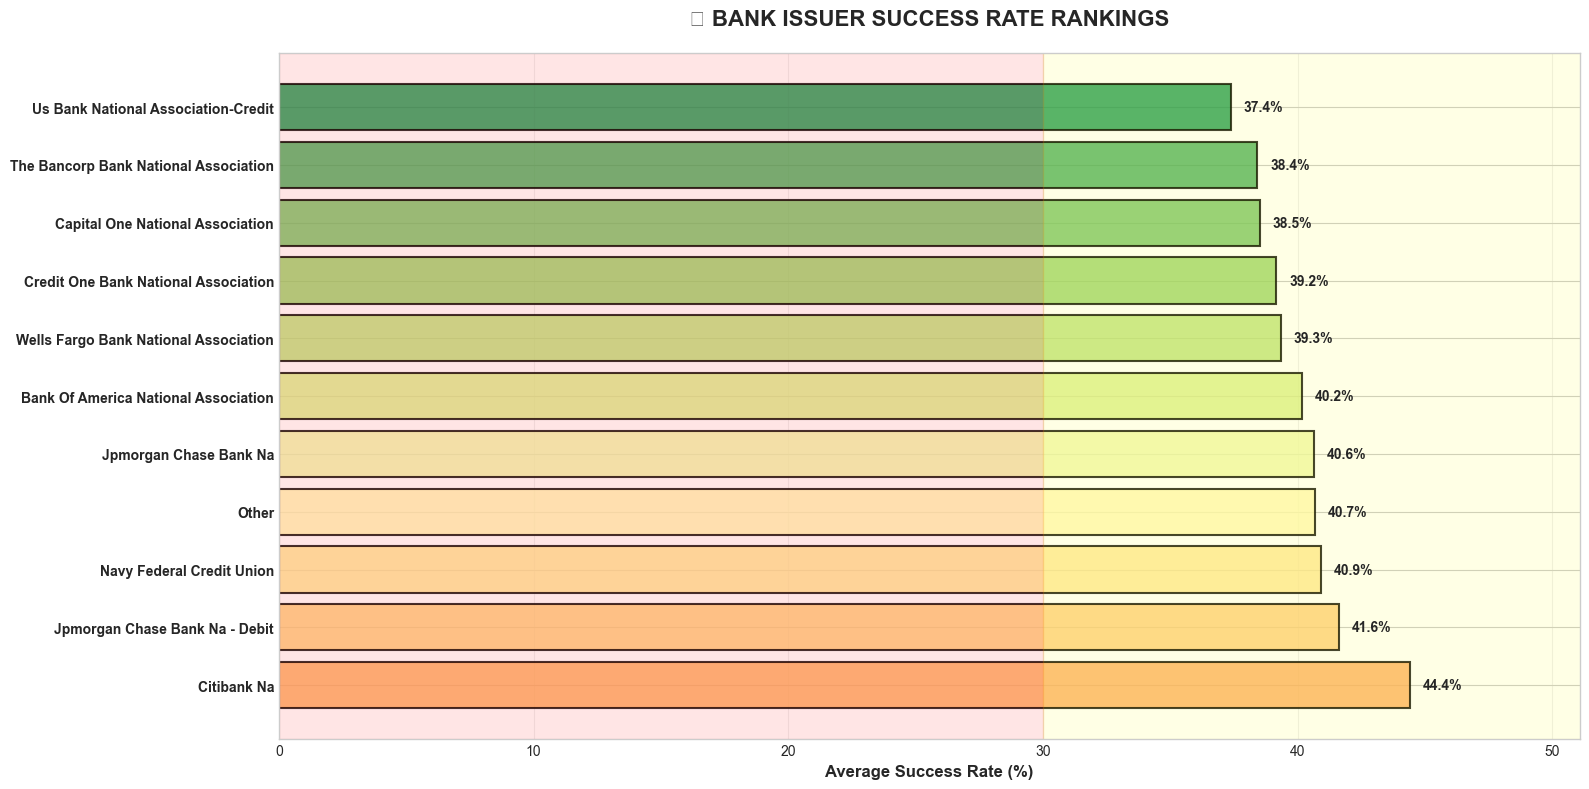


🏦 BANK ISSUER PERFORMANCE ANALYSIS

🥇 TOP 5 PERFORMING BANK ISSUERS:
   1. Citibank Na                              | Success: 44.4% | Volume: 29,169 | Revenue: $165,018
   2. Jpmorgan Chase Bank Na - Debit           | Success: 41.6% | Volume: 39,556 | Revenue: $215,379
   3. Navy Federal Credit Union                | Success: 40.9% | Volume: 23,143 | Revenue: $127,482
   4. Other                                    | Success: 40.7% | Volume: 78,269 | Revenue: $412,957
   5. Jpmorgan Chase Bank Na                   | Success: 40.6% | Volume: 49,171 | Revenue: $261,951

🥉 BOTTOM 5 PERFORMING BANK ISSUERS:
   1. Wells Fargo Bank National Association    | Success: 39.3% | Volume: 44,811 | Revenue: $236,093
   2. Credit One Bank National Association     | Success: 39.2% | Volume: 24,752 | Revenue: $130,537
   3. Capital One National Association         | Success: 38.5% | Volume: 56,590 | Revenue: $291,623
   4. The Bancorp Bank National Association    | Success: 38.4% | Volume: 23,693 | Re

In [ ]:
# Bank Issuer Success Rate Analysis
import matplotlib.pyplot as plt
import numpy as np

# Bank issuer columns
bank_issuers = [col for col in pooled_df.columns if col.startswith('bankissuer_')]

# Calculate success rates for each bank issuer
bank_performance = {}
for bank in bank_issuers:
    if bank in pooled_df.columns:
        # Get data where this bank issuer was used
        bank_data = pooled_df[pooled_df[bank] == 1]
        if len(bank_data) > 0:
            avg_success = bank_data['success_charge_ratess'].mean()
            total_volume = bank_data['attempted_charges'].sum()
            total_revenue = bank_data['gross_product_revenue'].sum()
            bank_name = bank.replace('bankissuer_', '').replace('_', ' ').title()
            bank_performance[bank_name] = {
                'success_rate': avg_success * 100,
                'volume': total_volume,
                'revenue': total_revenue
            }

# Sort by success rate
sorted_banks = sorted(bank_performance.items(), key=lambda x: x[1]['success_rate'], reverse=True)

# Create the visualization
fig, ax = plt.subplots(figsize=(16, 8))

# Create gradient colors
banks = [b[0] for b in sorted_banks]
rates = [b[1]['success_rate'] for b in sorted_banks]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_banks)))

bars = ax.barh(range(len(banks)), rates, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, rates)):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', ha='left', va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(banks)))
ax.set_yticklabels(banks, fontweight='bold')
ax.set_xlabel('Average Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('🏦 BANK ISSUER SUCCESS RATE RANKINGS', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, max(rates) * 1.15)

# Add performance zones
ax.axvspan(0, 30, alpha=0.1, color='red', label='Poor')
ax.axvspan(30, 60, alpha=0.1, color='yellow', label='Average')  
ax.axvspan(60, 100, alpha=0.1, color='green', label='Excellent')

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*80)
print("🏦 BANK ISSUER PERFORMANCE ANALYSIS")
print("="*80)

print(f"\n🥇 TOP 5 PERFORMING BANK ISSUERS:")
for i, (bank, stats) in enumerate(sorted_banks[:5], 1):
    print(f"   {i}. {bank:<40} | Success: {stats['success_rate']:.1f}% | Volume: {stats['volume']:,} | Revenue: ${stats['revenue']:,.0f}")

print(f"\n🥉 BOTTOM 5 PERFORMING BANK ISSUERS:")
for i, (bank, stats) in enumerate(sorted_banks[-5:], 1):
    print(f"   {i}. {bank:<40} | Success: {stats['success_rate']:.1f}% | Volume: {stats['volume']:,} | Revenue: ${stats['revenue']:,.0f}")

# Summary statistics
avg_success = np.mean(rates)
print(f"\n📊 OVERALL STATISTICS:")
print(f"Average success rate across all issuers: {avg_success:.1f}%")
print(f"Best performing issuer: {max(rates):.1f}%")
print(f"Worst performing issuer: {min(rates):.1f}%")
print(f"Performance range: {max(rates) - min(rates):.1f}%")

# Volume analysis
total_volume = sum([stats['volume'] for _, stats in sorted_banks])
print(f"\nTop 3 by volume:")
volume_sorted = sorted(bank_performance.items(), key=lambda x: x[1]['volume'], reverse=True)
for i, (bank, stats) in enumerate(volume_sorted[:3], 1):
    volume_share = (stats['volume'] / total_volume) * 100
    print(f"   {i}. {bank:<40} | Volume: {stats['volume']:,} ({volume_share:.1f}% of total)")

📉 MID DECAY PATTERN ANALYSIS

1. 📊 AVERAGE PERFORMANCE BY MID AGE:
--------------------------------------------------
Age Bucket | Success Rate | Revenue ($) | Volume | Records
-----------------------------------------------------------------
0-7d      | 0.435±0.226 |      73±    93 |     13 |   714.0
8-14d     | 0.430±0.215 |      96±   153 |     17 |   490.0
15-30d    | 0.406±0.248 |      45±    57 |      9 |   774.0
31-60d    | 0.427±0.181 |      71±    41 |     13 |  1443.0
61-90d    | 0.402±0.220 |      54±    40 |     10 |  1620.0
91-180d   | 0.367±0.220 |      49±    39 |     10 |  1828.0
181-365d  | nan±nan |     nan±   nan |    nan |     0.0
365d+     | nan±nan |     nan±   nan |    nan |     0.0

2. 🏢 INDIVIDUAL MID ANALYSIS:
--------------------------------------------------


C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\633369006.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = pooled_df.groupby('age_bucket').agg({


MIDs showing decline patterns: 61/97
Average success peak occurs at: 28 days
Average revenue peak occurs at: 44 days

🔻 TOP 5 MOST DECLINING MIDs (by success rate):
  MID    118.0: Trend=-0.740, Peak@  3d, Variance=0.0057
  MID    116.0: Trend=-0.679, Peak@  1d, Variance=0.0032
  MID    110.0: Trend=-0.546, Peak@  7d, Variance=0.0637
  MID    117.0: Trend=-0.493, Peak@  2d, Variance=0.0037
  MID    101.0: Trend=-0.443, Peak@ 13d, Variance=0.1500


C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\633369006.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\633369006.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\633369006.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\633369006.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\mmsou\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mmsou\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

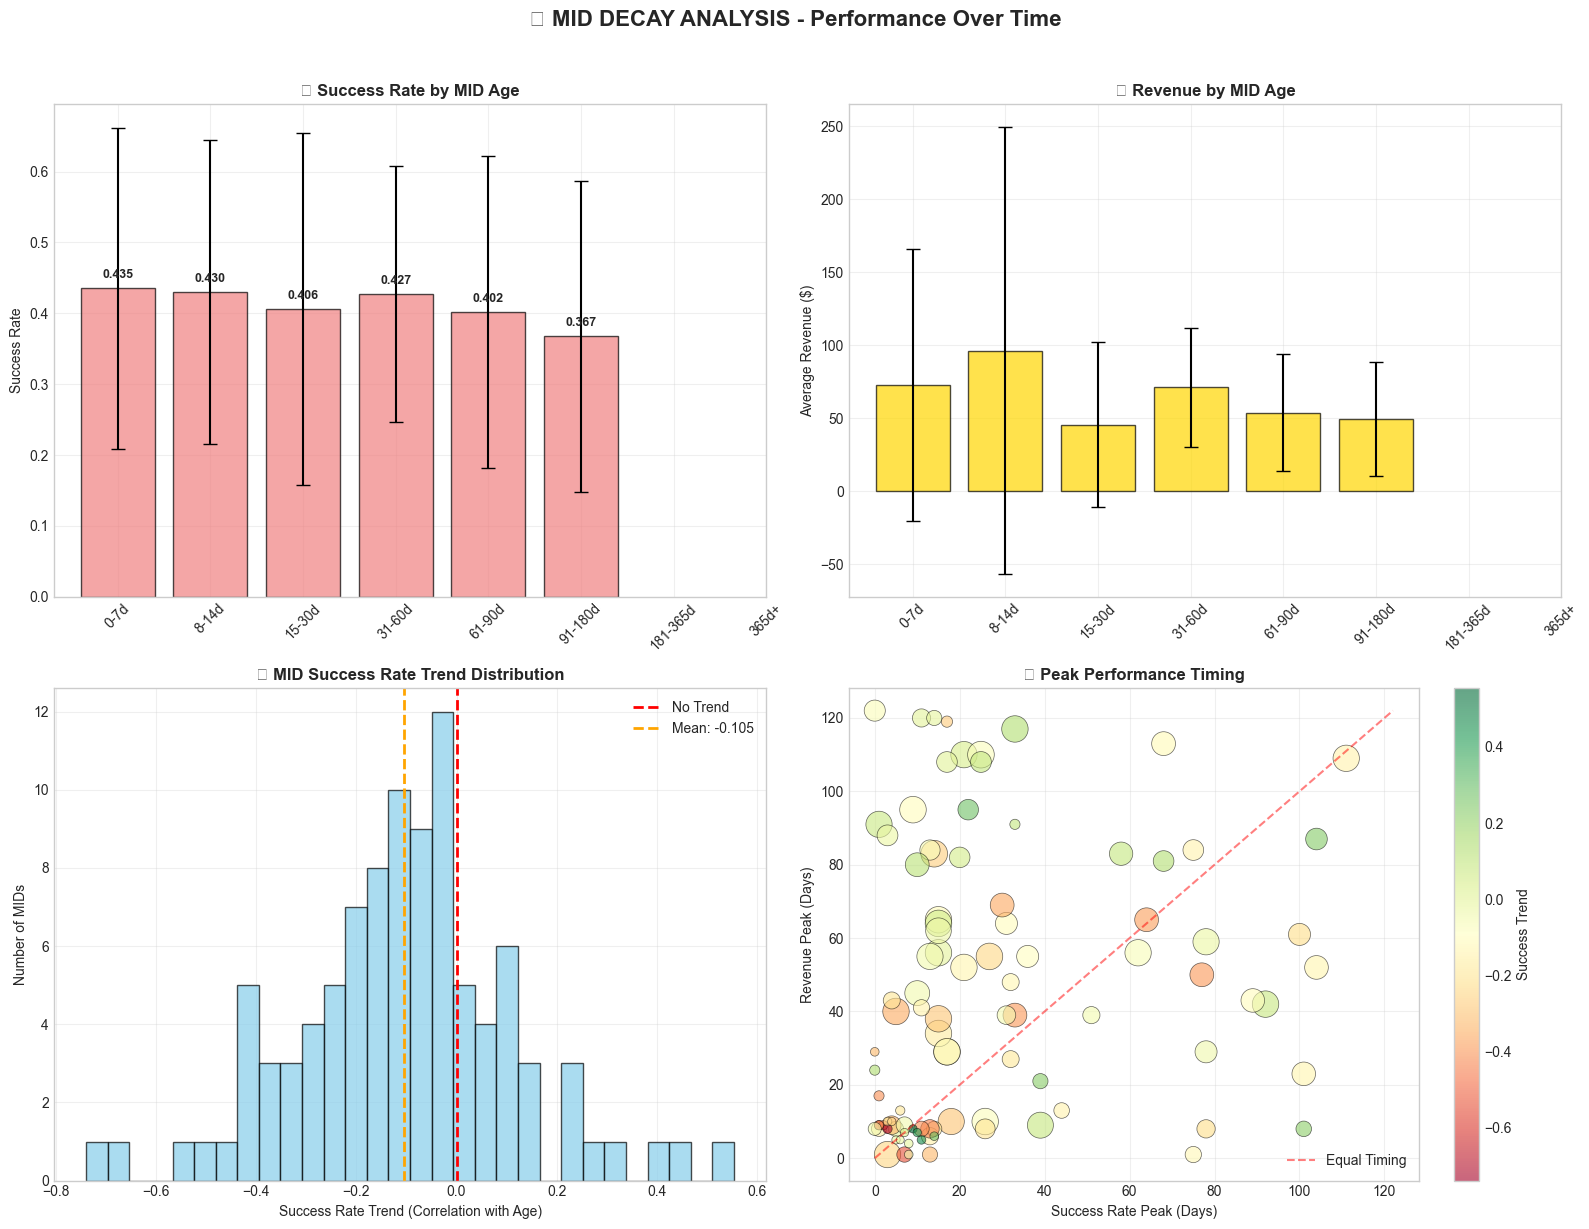


🎯 KEY DECAY INSIGHTS:
--------------------------------------------------
• 62.9% of MIDs show significant decline patterns
• Success rates peak around day 28
• Revenue peaks around day 44
• Steepest decline occurs in 91-180d period (-0.035 drop)
• Average success variance: 0.0517
• High variance MIDs (>0.05): 30

💡 RECOMMENDATIONS:
• Monitor MIDs closely after their peak performance period
• Consider refreshing/rotating MIDs showing decline trends
• Investigate what causes performance peaks to optimize timing
• Focus on MIDs with high variance - they may need attention


In [16]:
# MID DECAY ANALYSIS - When do MIDs start declining?
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

print("📉 MID DECAY PATTERN ANALYSIS")
print("="*60)

# Create age variable (days since first transaction for each MID)
pooled_df['date'] = pd.to_datetime(pooled_df['date'])
mid_first_date = pooled_df.groupby('mid')['date'].min().to_dict()
pooled_df['mid_age_days'] = pooled_df.apply(lambda row: (row['date'] - mid_first_date[row['mid']]).days, axis=1)

# Create age buckets
age_bins = [0, 7, 14, 30, 60, 90, 180, 365, 999]
age_labels = ['0-7d', '8-14d', '15-30d', '31-60d', '61-90d', '91-180d', '181-365d', '365d+']
pooled_df['age_bucket'] = pd.cut(pooled_df['mid_age_days'], bins=age_bins, labels=age_labels, include_lowest=True)

# 1. AGGREGATE DECAY PATTERNS
print("\n1. 📊 AVERAGE PERFORMANCE BY MID AGE:")
print("-" * 50)

age_analysis = pooled_df.groupby('age_bucket').agg({
    'success_charge_ratess': ['mean', 'std', 'count'],
    'gross_product_revenue': ['mean', 'std', 'count'],
    'attempted_charges': ['mean', 'std']
}).round(4)

age_analysis.columns = ['success_mean', 'success_std', 'success_count', 
                       'revenue_mean', 'revenue_std', 'revenue_count',
                       'volume_mean', 'volume_std']

print("Age Bucket | Success Rate | Revenue ($) | Volume | Records")
print("-" * 65)
for bucket in age_labels:
    if bucket in age_analysis.index:
        stats = age_analysis.loc[bucket]
        print(f"{bucket:9} | {stats['success_mean']:.3f}±{stats['success_std']:.3f} | "
              f"{stats['revenue_mean']:7.0f}±{stats['revenue_std']:6.0f} | "
              f"{stats['volume_mean']:6.0f} | {stats['success_count']:7}")

# 2. INDIVIDUAL MID DECAY PATTERNS
print(f"\n2. 🏢 INDIVIDUAL MID ANALYSIS:")
print("-" * 50)

mid_decay_stats = []
for mid in pooled_df['mid'].unique():
    mid_data = pooled_df[pooled_df['mid'] == mid].copy()
    if len(mid_data) >= 10:  # At least 10 records for meaningful analysis
        mid_data = mid_data.sort_values('date')
        
        # Calculate trend using correlation with time
        mid_data['days_from_start'] = (mid_data['date'] - mid_data['date'].min()).dt.days
        success_trend = mid_data['days_from_start'].corr(mid_data['success_charge_ratess'])
        revenue_trend = mid_data['days_from_start'].corr(mid_data['gross_product_revenue'])
        
        # Calculate when performance starts declining (if at all)
        success_peak_day = mid_data.loc[mid_data['success_charge_ratess'].idxmax(), 'days_from_start']
        revenue_peak_day = mid_data.loc[mid_data['gross_product_revenue'].idxmax(), 'days_from_start']
        
        mid_decay_stats.append({
            'mid': mid,
            'total_days': mid_data['days_from_start'].max(),
            'success_trend': success_trend,
            'revenue_trend': revenue_trend,
            'success_peak_day': success_peak_day,
            'revenue_peak_day': revenue_peak_day,
            'success_variance': mid_data['success_charge_ratess'].var(),
            'revenue_variance': mid_data['gross_product_revenue'].var(),
            'records': len(mid_data)
        })

mid_decay_df = pd.DataFrame(mid_decay_stats)

# Identify decaying MIDs
decaying_mids = mid_decay_df[
    (mid_decay_df['success_trend'] < -0.1) | (mid_decay_df['revenue_trend'] < -0.1)
]

print(f"MIDs showing decline patterns: {len(decaying_mids)}/{len(mid_decay_df)}")
print(f"Average success peak occurs at: {mid_decay_df['success_peak_day'].mean():.0f} days")
print(f"Average revenue peak occurs at: {mid_decay_df['revenue_peak_day'].mean():.0f} days")

# Top 5 most declining MIDs
print(f"\n🔻 TOP 5 MOST DECLINING MIDs (by success rate):")
worst_decline = decaying_mids.nsmallest(5, 'success_trend')
for _, row in worst_decline.iterrows():
    print(f"  MID {row['mid']:8}: Trend={row['success_trend']:6.3f}, Peak@{row['success_peak_day']:3.0f}d, Variance={row['success_variance']:.4f}")

# 3. VISUALIZATIONS
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Success Rate Decay Over Time
age_means = [age_analysis.loc[bucket, 'success_mean'] if bucket in age_analysis.index else 0 for bucket in age_labels]
age_stds = [age_analysis.loc[bucket, 'success_std'] if bucket in age_analysis.index else 0 for bucket in age_labels]

bars1 = ax1.bar(range(len(age_labels)), age_means, yerr=age_stds, capsize=5, 
                color='lightcoral', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(age_labels)))
ax1.set_xticklabels(age_labels, rotation=45)
ax1.set_ylabel('Success Rate')
ax1.set_title('📉 Success Rate by MID Age', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add value labels
for i, (bar, mean) in enumerate(zip(bars1, age_means)):
    if mean > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 2: Revenue Decay Over Time
rev_means = [age_analysis.loc[bucket, 'revenue_mean'] if bucket in age_analysis.index else 0 for bucket in age_labels]
rev_stds = [age_analysis.loc[bucket, 'revenue_std'] if bucket in age_analysis.index else 0 for bucket in age_labels]

bars2 = ax2.bar(range(len(age_labels)), rev_means, yerr=rev_stds, capsize=5,
                color='gold', alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(age_labels)))
ax2.set_xticklabels(age_labels, rotation=45)
ax2.set_ylabel('Average Revenue ($)')
ax2.set_title('💰 Revenue by MID Age', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Chart 3: MID Trend Distribution
ax3.hist(mid_decay_df['success_trend'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='No Trend')
ax3.axvline(mid_decay_df['success_trend'].mean(), color='orange', linestyle='--', linewidth=2, 
           label=f'Mean: {mid_decay_df["success_trend"].mean():.3f}')
ax3.set_xlabel('Success Rate Trend (Correlation with Age)')
ax3.set_ylabel('Number of MIDs')
ax3.set_title('📊 MID Success Rate Trend Distribution', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Chart 4: Peak Performance Timing
ax4.scatter(mid_decay_df['success_peak_day'], mid_decay_df['revenue_peak_day'], 
           c=mid_decay_df['success_trend'], cmap='RdYlGn', alpha=0.6, 
           s=mid_decay_df['records']*3, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Success Rate Peak (Days)')
ax4.set_ylabel('Revenue Peak (Days)')
ax4.set_title('🎯 Peak Performance Timing', fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add diagonal line
max_val = max(mid_decay_df['success_peak_day'].max(), mid_decay_df['revenue_peak_day'].max())
ax4.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal Timing')
ax4.legend()

plt.colorbar(ax4.collections[0], ax=ax4, label='Success Trend')

plt.suptitle('📉 MID DECAY ANALYSIS - Performance Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. KEY INSIGHTS
print(f"\n🎯 KEY DECAY INSIGHTS:")
print("-" * 50)
declining_pct = (len(decaying_mids) / len(mid_decay_df)) * 100
print(f"• {declining_pct:.1f}% of MIDs show significant decline patterns")
print(f"• Success rates peak around day {mid_decay_df['success_peak_day'].mean():.0f}")
print(f"• Revenue peaks around day {mid_decay_df['revenue_peak_day'].mean():.0f}")

# Find the age bucket with steepest decline
age_diffs = []
for i in range(1, len(age_means)):
    if age_means[i] > 0 and age_means[i-1] > 0:
        diff = age_means[i] - age_means[i-1]
        age_diffs.append((age_labels[i], diff))

if age_diffs:
    steepest_decline = min(age_diffs, key=lambda x: x[1])
    print(f"• Steepest decline occurs in {steepest_decline[0]} period ({steepest_decline[1]:.3f} drop)")

print(f"• Average success variance: {mid_decay_df['success_variance'].mean():.4f}")
print(f"• High variance MIDs (>0.05): {len(mid_decay_df[mid_decay_df['success_variance'] > 0.05])}")

print(f"\n💡 RECOMMENDATIONS:")
print("• Monitor MIDs closely after their peak performance period")
print("• Consider refreshing/rotating MIDs showing decline trends")
print("• Investigate what causes performance peaks to optimize timing")
print("• Focus on MIDs with high variance - they may need attention")

#### **5) Checking stats comparisosn between the two affiliates - General**

#### **6) Checking stats comparisosn between the two affiliates - Correlations**

In [17]:
# LAG CORRELATION ANALYSIS - Check if adding lags improves correlations
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("⏰ LAG CORRELATION ANALYSIS (1-30 Days)")
print("="*70)

# Columns to test with lags (excluding the -1.0000 correlations as they're already perfect)
test_columns = [
    'processing_fees_rate', 'net_revenue', 'adjustment_rate', 'alert_rate', 
    'alert_revenue_rate', 'adjustments', 'processing_fees', 'alerts', 
    'alert_revenue', 'cost_of_revenue', 'void_rate', 'refund_rate',
    'chargeback_rate', 'chargeback_fees_rate'
]

# Filter existing columns
test_columns = [col for col in test_columns if col in pooled_df.columns]

# Sort data by mid and date for proper lagging
pooled_df_sorted = pooled_df.sort_values(['mid', 'date']).copy()

print(f"Testing {len(test_columns)} variables with lags 1-30 days...")
print("\nOriginal correlations vs best lag correlations:")
print("-" * 80)

lag_results = {}
best_improvements = []

for col in test_columns:
    original_corr = pooled_df['success_charge_ratess'].corr(pooled_df[col])
    
    best_lag = 0
    best_corr = original_corr
    lag_correlations = {}
    
    # Test lags 1-30 days
    for lag in range(1, 31):
        # Create lagged variable
        pooled_df_sorted[f'{col}_lag_{lag}'] = pooled_df_sorted.groupby('mid')[col].shift(lag)
        
        # Calculate correlation
        lagged_corr = pooled_df_sorted['success_charge_ratess'].corr(pooled_df_sorted[f'{col}_lag_{lag}'])
        
        if not pd.isna(lagged_corr) and abs(lagged_corr) > abs(best_corr):
            best_corr = lagged_corr
            best_lag = lag
            
        lag_correlations[lag] = lagged_corr
        
        # Clean up the temporary column
        pooled_df_sorted = pooled_df_sorted.drop(columns=[f'{col}_lag_{lag}'])
    
    # Store results
    lag_results[col] = {
        'original': original_corr,
        'best_lag': best_lag,
        'best_corr': best_corr,
        'improvement': abs(best_corr) - abs(original_corr),
        'all_lags': lag_correlations
    }
    
    # Print results
    improvement = abs(best_corr) - abs(original_corr)
    status = "📈 IMPROVED" if improvement > 0.05 else "➡️  SIMILAR" if improvement > 0.01 else "📉 UNCHANGED"
    
    print(f"{col:<30} | Orig: {original_corr:7.4f} | Best: {best_corr:7.4f} (lag {best_lag:2d}) | {status}")
    
    if improvement > 0.05:  # Significant improvement
        best_improvements.append({
            'column': col,
            'original': original_corr,
            'best': best_corr,
            'lag': best_lag,
            'improvement': improvement
        })

# Sort improvements by magnitude
best_improvements = sorted(best_improvements, key=lambda x: x['improvement'], reverse=True)

print(f"\n🚀 SIGNIFICANT IMPROVEMENTS (>0.05 absolute correlation increase):")
print("-" * 70)
if best_improvements:
    for imp in best_improvements:
        print(f"• {imp['column']:<25}: {imp['original']:7.4f} → {imp['best']:7.4f} (lag {imp['lag']:2d}d) +{imp['improvement']:.4f}")
else:
    print("No significant improvements found with lagged variables.")

# Create visualization for top improvements
if best_improvements:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Plot top 4 improvements (or fewer if less available)
    for i, imp in enumerate(best_improvements[:4]):
        col = imp['column']
        best_lag = imp['lag']
        
        # Create the best lagged variable for plotting
        pooled_df_sorted[f'{col}_best_lag'] = pooled_df_sorted.groupby('mid')[col].shift(best_lag)
        
        # Plot lag correlation over time
        lag_range = range(1, min(31, len(lag_results[col]['all_lags']) + 1))
        correlations = [lag_results[col]['all_lags'].get(lag, 0) for lag in lag_range]
        
        axes[i].plot(lag_range, [abs(c) for c in correlations], 'b-', linewidth=2, alpha=0.7, label='Absolute Correlation')
        axes[i].axhline(abs(imp['original']), color='red', linestyle='--', alpha=0.7, label='Original')
        axes[i].axvline(best_lag, color='green', linestyle='--', alpha=0.7, label=f'Best (lag {best_lag})')
        axes[i].scatter([best_lag], [abs(imp['best'])], color='green', s=100, zorder=5)
        
        axes[i].set_xlabel('Lag (days)')
        axes[i].set_ylabel('Absolute Correlation')
        axes[i].set_title(f'{col.replace("_", " ").title()}\nImprovement: +{imp["improvement"]:.4f}', fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
        
        # Clean up
        pooled_df_sorted = pooled_df_sorted.drop(columns=[f'{col}_best_lag'])
    
    # Hide unused subplots
    for i in range(len(best_improvements), 4):
        axes[i].set_visible(False)
    
    plt.suptitle('⏰ LAG CORRELATION IMPROVEMENTS', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Summary table of all variables with their best lags
print(f"\n📊 COMPLETE RESULTS SUMMARY:")
print("-" * 80)
print(f"{'Variable':<25} {'Original':<10} {'Best Lag':<10} {'Best Corr':<10} {'Improvement':<12}")
print("-" * 80)

for col in sorted(lag_results.keys()):
    result = lag_results[col]
    print(f"{col:<25} {result['original']:8.4f} {result['best_lag']:8d} {result['best_corr']:9.4f} {result['improvement']:10.4f}")

print(f"\n🎯 KEY FINDINGS:")
print("-" * 50)
print(f"• Variables tested: {len(test_columns)}")
print(f"• Significant improvements: {len(best_improvements)}")
if best_improvements:
    avg_improvement = np.mean([imp['improvement'] for imp in best_improvements])
    best_lag_days = [imp['lag'] for imp in best_improvements]
    print(f"• Average improvement: +{avg_improvement:.4f}")
    print(f"• Best lag periods: {min(best_lag_days)}-{max(best_lag_days)} days")
    print(f"• Most common improvement lag: {max(set(best_lag_days), key=best_lag_days.count)} days")
else:
    print("• Most variables perform best with no lag (same-day data)")
    print("• Consider that payment processing is largely real-time")

print(f"\n💡 RECOMMENDATIONS:")
if best_improvements:
    print("• Use lagged features for variables showing significant improvement")
    print("• Consider ensemble models combining current + lagged features")
    print("• Test these lag patterns on other similar datasets")
else:
    print("• Current-day features appear optimal for success rate prediction") 
    print("• Payment processing relationships are largely contemporaneous")
    print("• Focus on real-time optimization rather than historical patterns")

⏰ LAG CORRELATION ANALYSIS (1-30 Days)
Testing 14 variables with lags 1-30 days...

Original correlations vs best lag correlations:
--------------------------------------------------------------------------------
processing_fees_rate           | Orig:  0.8878 | Best:  0.8878 (lag  0) | 📉 UNCHANGED
net_revenue                    | Orig:  0.2844 | Best:  0.2844 (lag  0) | 📉 UNCHANGED
adjustment_rate                | Orig:  0.2719 | Best:  0.2719 (lag  0) | 📉 UNCHANGED
alert_rate                     | Orig:  0.2446 | Best:  0.2446 (lag  0) | 📉 UNCHANGED
alert_revenue_rate             | Orig:  0.2446 | Best:  0.2446 (lag  0) | 📉 UNCHANGED
adjustments                    | Orig:  0.1971 | Best:  0.1971 (lag  0) | 📉 UNCHANGED
processing_fees                | Orig:  0.1851 | Best:  0.1851 (lag  0) | 📉 UNCHANGED
alerts                         | Orig:  0.1815 | Best:  0.1815 (lag  0) | 📉 UNCHANGED
alert_revenue                  | Orig:  0.1815 | Best:  0.1815 (lag  0) | 📉 UNCHANGED
cost_of_reven

💰 PROCESSING FEES RATE vs SUCCESS RATE ANALYSIS
📊 CORRELATION: 0.8878 (Very Strong Positive)
------------------------------------------------------------
📈 DESCRIPTIVE STATISTICS:
------------------------------
Processing Fees Rate:
  Mean: 0.0252
  Std:  0.0147
  Min:  0.0000
  Max:  0.0704

Success Charge Rate:
  Mean: 0.4041
  Std:  0.2174
  Min:  0.0000
  Max:  1.0000

📊 BINNED ANALYSIS:
------------------------------
Fees Level      | Success Rate | Std Dev  | Count
--------------------------------------------------
Very Low       |      0.1635 |  0.2038 |  1378
Low            |      0.2845 |  0.0431 |  1395
Medium         |      0.3878 |  0.0354 |  1366
High           |      0.4898 |  0.0303 |  1391
Very High      |      0.7042 |  0.1523 |  1339


C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\3035641351.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis = pooled_df.groupby('fees_bin')['success_charge_ratess'].agg(['mean', 'std', 'count']).round(4)
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\3035641351.py:112: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\3035641351.py:112: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\3035641351.py:112: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmsou\AppData\Local\Temp\ipykernel_29736\3035641351.py:112: UserWarning: Glyph 12

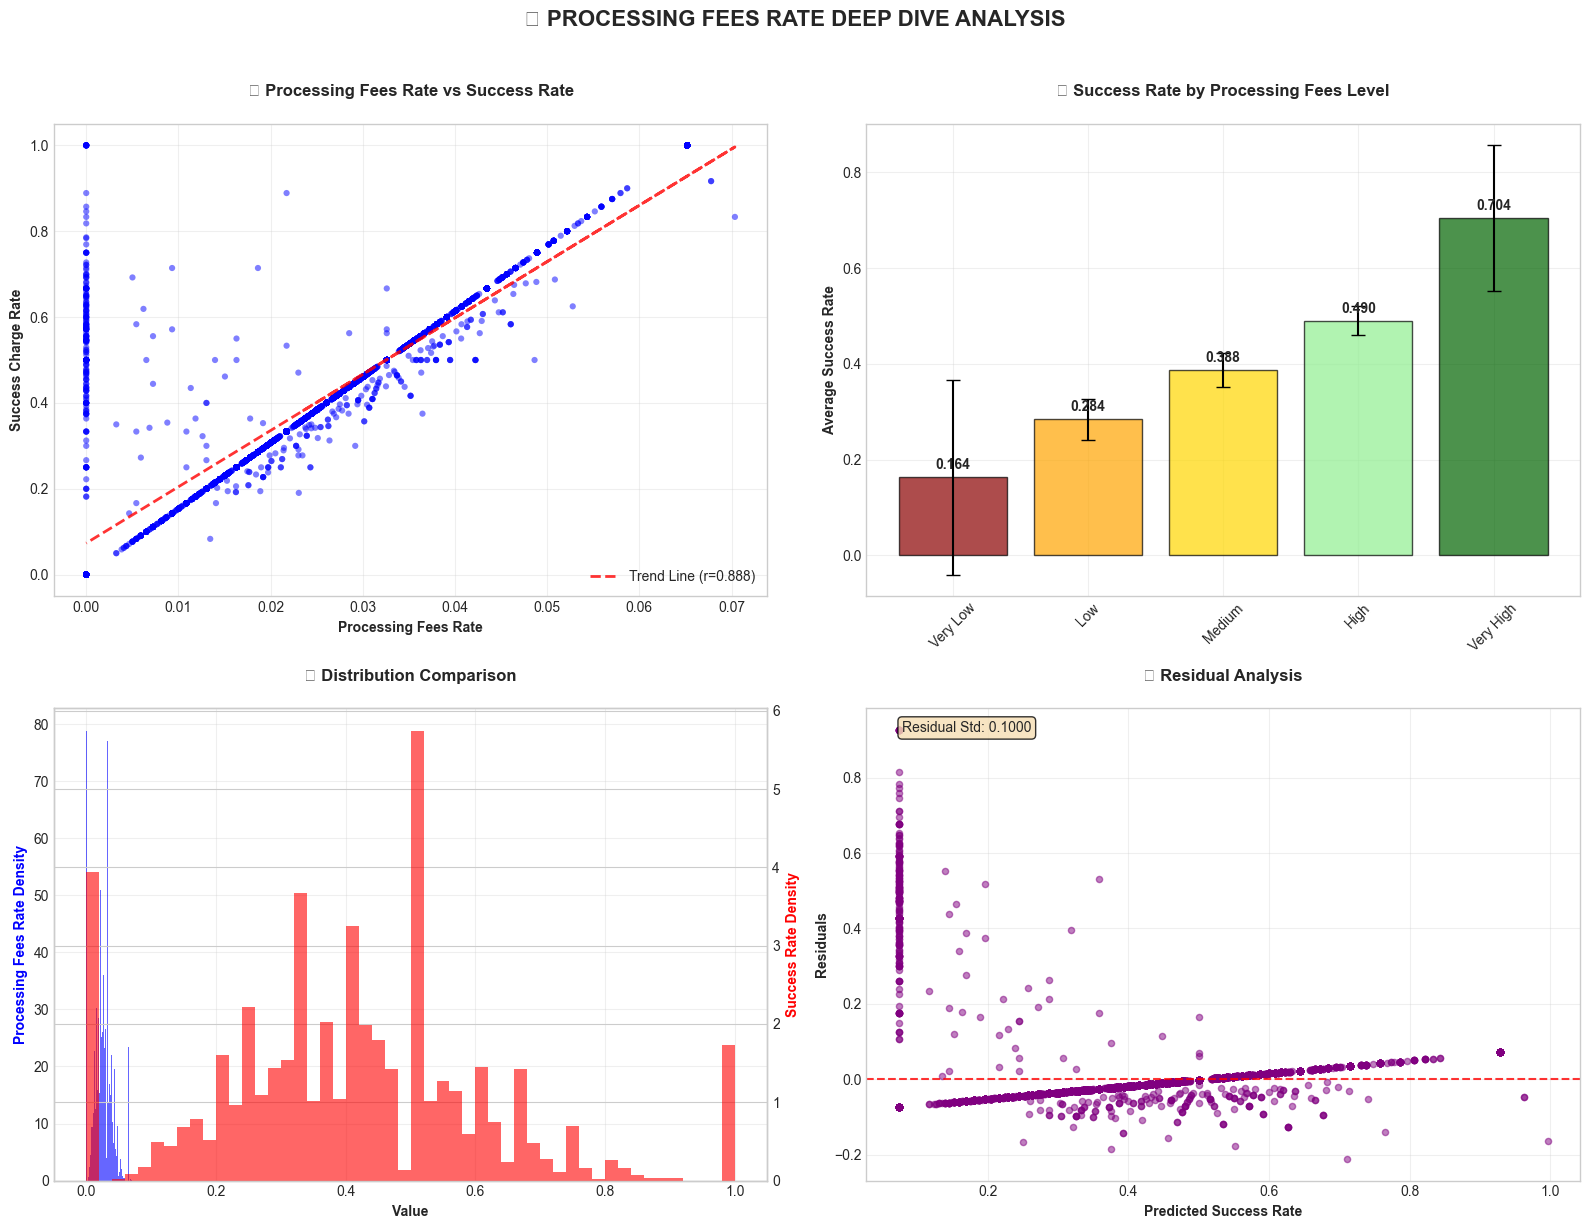


🎯 KEY INSIGHTS:
--------------------------------------------------
• R-squared: 0.7882 (78.8% of variance explained)
• Effect Size: Very Large Effect
• Max Success Rate Impact: 0.923 across full fees range
• Processing fees outliers: 233 (3.4%)

💡 BUSINESS IMPLICATIONS:
--------------------------------------------------
• Higher processing fees are strongly associated with higher success rates
• This suggests premium processors/routes have better approval rates
• Consider cost-benefit analysis: higher fees vs higher success rates
• May indicate that 'you get what you pay for' in payment processing
• Could guide pricing strategy and processor selection decisions
• Monitor if this relationship holds across different affiliates/products

🔍 BY AFFILIATE ANALYSIS:
------------------------------
Affiliate 1: Correlation = 0.8656
Affiliate 15: Correlation = 0.9963

🎯 OPTIMAL PERFORMANCE:
• Best performing fees level: Very High
• Success rate at optimal level: 0.7042


In [18]:
# DEEP DIVE: Processing Fees Rate vs Success Rate Analysis
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("💰 PROCESSING FEES RATE vs SUCCESS RATE ANALYSIS")
print("="*60)

# Basic statistics
correlation = pooled_df['processing_fees_rate'].corr(pooled_df['success_charge_ratess'])
print(f"📊 CORRELATION: {correlation:.4f} (Very Strong Positive)")
print("-" * 60)

# Descriptive statistics
print("📈 DESCRIPTIVE STATISTICS:")
print("-" * 30)
print("Processing Fees Rate:")
print(f"  Mean: {pooled_df['processing_fees_rate'].mean():.4f}")
print(f"  Std:  {pooled_df['processing_fees_rate'].std():.4f}")
print(f"  Min:  {pooled_df['processing_fees_rate'].min():.4f}")
print(f"  Max:  {pooled_df['processing_fees_rate'].max():.4f}")

print("\nSuccess Charge Rate:")
print(f"  Mean: {pooled_df['success_charge_ratess'].mean():.4f}")
print(f"  Std:  {pooled_df['success_charge_ratess'].std():.4f}")
print(f"  Min:  {pooled_df['success_charge_ratess'].min():.4f}")
print(f"  Max:  {pooled_df['success_charge_ratess'].max():.4f}")

# Binned analysis
print(f"\n📊 BINNED ANALYSIS:")
print("-" * 30)
# Create processing fees rate bins
pooled_df['fees_bin'] = pd.qcut(pooled_df['processing_fees_rate'], 5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

bin_analysis = pooled_df.groupby('fees_bin')['success_charge_ratess'].agg(['mean', 'std', 'count']).round(4)
print("Fees Level      | Success Rate | Std Dev  | Count")
print("-" * 50)
for bin_name in ['Very Low', 'Low', 'Medium', 'High', 'Very High']:
    if bin_name in bin_analysis.index:
        stats = bin_analysis.loc[bin_name]
        print(f"{bin_name:14} | {stats['mean']:11.4f} | {stats['std']:7.4f} | {stats['count']:5.0f}")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter Plot with Regression Line
ax1.scatter(pooled_df['processing_fees_rate'], pooled_df['success_charge_ratess'], 
           alpha=0.5, c='blue', s=20, edgecolors='none')

# Add regression line
z = np.polyfit(pooled_df['processing_fees_rate'], pooled_df['success_charge_ratess'], 1)
p = np.poly1d(z)
ax1.plot(pooled_df['processing_fees_rate'], p(pooled_df['processing_fees_rate']), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend Line (r={correlation:.3f})')

ax1.set_xlabel('Processing Fees Rate', fontweight='bold')
ax1.set_ylabel('Success Charge Rate', fontweight='bold')
ax1.set_title('💰 Processing Fees Rate vs Success Rate', fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Binned Bar Chart
bin_means = [bin_analysis.loc[bin_name, 'mean'] if bin_name in bin_analysis.index else 0 
             for bin_name in ['Very Low', 'Low', 'Medium', 'High', 'Very High']]
bin_stds = [bin_analysis.loc[bin_name, 'std'] if bin_name in bin_analysis.index else 0 
            for bin_name in ['Very Low', 'Low', 'Medium', 'High', 'Very High']]

colors = ['darkred', 'orange', 'gold', 'lightgreen', 'darkgreen']
bars = ax2.bar(range(5), bin_means, yerr=bin_stds, capsize=5, 
               color=colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(5))
ax2.set_xticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'], rotation=45)
ax2.set_ylabel('Average Success Rate', fontweight='bold')
ax2.set_title('📊 Success Rate by Processing Fees Level', fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, mean) in enumerate(zip(bars, bin_means)):
    if mean > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Distribution Comparison
ax3.hist(pooled_df['processing_fees_rate'], bins=50, alpha=0.6, color='blue', 
         density=True, label='Processing Fees Rate')
ax3_twin = ax3.twinx()
ax3_twin.hist(pooled_df['success_charge_ratess'], bins=50, alpha=0.6, color='red',
              density=True, label='Success Rate')
ax3.set_xlabel('Value', fontweight='bold')
ax3.set_ylabel('Processing Fees Rate Density', color='blue', fontweight='bold')
ax3_twin.set_ylabel('Success Rate Density', color='red', fontweight='bold')
ax3.set_title('📈 Distribution Comparison', fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3)

# 4. Residual Analysis
predicted = p(pooled_df['processing_fees_rate'])
residuals = pooled_df['success_charge_ratess'] - predicted

ax4.scatter(predicted, residuals, alpha=0.5, c='purple', s=20)
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.8)
ax4.set_xlabel('Predicted Success Rate', fontweight='bold')
ax4.set_ylabel('Residuals', fontweight='bold')
ax4.set_title('📉 Residual Analysis', fontweight='bold', pad=20)
ax4.grid(True, alpha=0.3)

# Add residual statistics
residual_std = np.std(residuals)
ax4.text(0.05, 0.95, f'Residual Std: {residual_std:.4f}', transform=ax4.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('💰 PROCESSING FEES RATE DEEP DIVE ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Advanced insights
print(f"\n🎯 KEY INSIGHTS:")
print("-" * 50)

# R-squared calculation
r_squared = correlation ** 2
print(f"• R-squared: {r_squared:.4f} ({r_squared*100:.1f}% of variance explained)")

# Effect size interpretation
if abs(correlation) >= 0.8:
    effect_size = "Very Large Effect"
elif abs(correlation) >= 0.5:
    effect_size = "Large Effect" 
elif abs(correlation) >= 0.3:
    effect_size = "Medium Effect"
else:
    effect_size = "Small Effect"

print(f"• Effect Size: {effect_size}")

# Business impact calculation
fees_range = pooled_df['processing_fees_rate'].max() - pooled_df['processing_fees_rate'].min()
success_impact = correlation * (pooled_df['success_charge_ratess'].std() / pooled_df['processing_fees_rate'].std()) * fees_range
print(f"• Max Success Rate Impact: {success_impact:.3f} across full fees range")

# Outlier analysis
q1_fees = pooled_df['processing_fees_rate'].quantile(0.25)
q3_fees = pooled_df['processing_fees_rate'].quantile(0.75)
iqr_fees = q3_fees - q1_fees
outliers = pooled_df[(pooled_df['processing_fees_rate'] < q1_fees - 1.5*iqr_fees) | 
                    (pooled_df['processing_fees_rate'] > q3_fees + 1.5*iqr_fees)]
print(f"• Processing fees outliers: {len(outliers)} ({len(outliers)/len(pooled_df)*100:.1f}%)")

print(f"\n💡 BUSINESS IMPLICATIONS:")
print("-" * 50)
print("• Higher processing fees are strongly associated with higher success rates")
print("• This suggests premium processors/routes have better approval rates")
print("• Consider cost-benefit analysis: higher fees vs higher success rates")
print("• May indicate that 'you get what you pay for' in payment processing")
print("• Could guide pricing strategy and processor selection decisions")
print("• Monitor if this relationship holds across different affiliates/products")

# Check by affiliate
print(f"\n🔍 BY AFFILIATE ANALYSIS:")
print("-" * 30)
for affiliate in [1, 15]:
    aff_data = pooled_df[pooled_df['affiliate_id'] == affiliate]
    aff_corr = aff_data['processing_fees_rate'].corr(aff_data['success_charge_ratess'])
    print(f"Affiliate {affiliate}: Correlation = {aff_corr:.4f}")

# Optimal fees analysis
optimal_bin = bin_analysis['mean'].idxmax()
optimal_success = bin_analysis.loc[optimal_bin, 'mean']
print(f"\n🎯 OPTIMAL PERFORMANCE:")
print(f"• Best performing fees level: {optimal_bin}")
print(f"• Success rate at optimal level: {optimal_success:.4f}")